<a href="https://colab.research.google.com/github/michaelraykuster-spec/Werkplaats-2-opdracht-Groep-3/blob/main/Werkplaats_2_opdracht_Groep_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Boilerplate

Dit is boiletplate code om diverse functies in te laden

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import nltk
import yfinance as yf

from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from textblob import TextBlob
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import date
from transformers import pipeline
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tabulate import tabulate
from matplotlib.ticker import FuncFormatter

#Clear output
from google.colab import output
output.clear()

In [ ]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)

#Lesweek 1

We gaan een portfolio maken via Yahoo Finance en we gaan macro-economische data inlezen bij de FED in St. Louis: https://fred.stlouisfed.org/categories

Hier wordt de begin, einddatum en de cijfers van de diverse items in de portfolio ingeladen.

In [ ]:
start = dt.datetime(2015,12,25)
end = dt.datetime.today()

#Aandelen, Crypto's en obligaties
CBOE_interest = yf.download('^TNX', start, end).tz_localize(None)
yield5 = yf.download('^FVX', start, end).tz_localize(None)
broadcom  = yf.download('AVGO', start, end).tz_localize(None)
bitcoin = yf.download('BTC-USD', start, end).tz_localize(None)
qualcomm = yf.download('QCOM', start, end).tz_localize(None)
stellan = yf.download('STLA', start, end).tz_localize(None)
asml = yf.download('ASML', start, end).tz_localize(None)
netflix = yf.download('NFLX', start, end).tz_localize(None)
apple = yf.download('AAPL', start, end).tz_localize(None)
shell = yf.download('SHEL', start, end).tz_localize(None)

#Grondstoffen
graan = web.get_data_fred('PWHEAMTUSDM', start, end) #graan
hout = web.get_data_fred('WPU08', start, end) #hout
koffie = web.get_data_fred('WPU026301', start, end) #koffiebonen
gas = web.get_data_fred('GASREGW', start, end) #gas (US Regular All Formulations Gas Price)
goud = yf.download('GC=F', start, end).tz_localize(None) #goud future
olie = yf.download('CL=F', start, end).tz_localize(None) #olie
koper = web.get_data_fred('PCOPPUSDM', start, end) #koperprijs
staal = web.get_data_fred('WPU101707', start, end) #staal (Producer Price Index by Commodity: Metals and Metal Products: Cold Rolled Steel Sheet and Strip )
zilver = yf.download('SI=F', start, end).tz_localize(None) #zilver future
katoen = web.get_data_fred('PCOTTINDUSDM', start, end) #katoen

#Economische indicatoren
inflatie_10y = web.get_data_fred('T10YIE', start, end) #10-Year Breakeven Inflation Rate
fed_funds = web.get_data_fred('FEDFUNDS', start, end) #Federal Funds Effective Rate, het rente percentage op leningen in Amerika
werkloosheid = web.get_data_fred('UNRATE', start, end) #het werkloosheidspercentage in Amerika
bbp = web.get_data_fred('GDP', start, end) #Het BBP in Amerika
persoonlijk_inkomen = web.get_data_fred('PI', start, end) #Persoonlijk inkomen in Amerika
output.clear()

Dit is de kolommen juiste namen geven

In [ ]:
def select_close(df, naam):
    df = df[["Close"]].copy()
    df.columns = [naam]  # force single-level
    return df

def rename_fred(df, naam):
    df.columns = [naam]
    return df

samengevoegd = pd.concat([

    # Yahoo (Close)
    select_close(CBOE_interest, "Close_CBOE_interest"),
    select_close(yield5, "Close_5Y_Yield"),
    select_close(broadcom, "Close_Broadcom"),
    select_close(bitcoin, "Close_Bitcoin"),
    select_close(qualcomm, "Close_Qualcomm"),
    select_close(stellan, "Close_Stellantis"),
    select_close(asml, "Close_ASML"),
    select_close(netflix, "Close_Netflix"),
    select_close(apple, "Close_Apple"),
    select_close(shell, "Close_Shell"),
    select_close(goud, "Close_Gold"),
    select_close(olie, "Close_Oil"),
    select_close(zilver, "Close_Silver"),

    # FRED (direct rename)
    rename_fred(graan, "Grain"),
    rename_fred(hout, "Wood"),
    rename_fred(koffie, "Coffee"),
    rename_fred(gas, "Gasoline"),
    rename_fred(koper, "Copper"),
    rename_fred(staal, "Steel"),
    rename_fred(katoen, "Cotton"),

    #Economische indicatoren
    rename_fred(inflatie_10y, "Inflatie_10y"),
    rename_fred(fed_funds, "Fed_Funds"),
    rename_fred(werkloosheid, "Unemployment"),
    rename_fred(bbp, "GDP"),
    rename_fred(persoonlijk_inkomen, "Income")

], axis=1)

# Resultaat
samengevoegd.head()

,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income
2015-12-25,NaN,NaN,NaN,455.653015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-26,NaN,NaN,NaN,417.273987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-27,NaN,NaN,NaN,422.822998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-28,2.225,1.716,11.164366,422.278992,37.168049,4.985762,82.524063,11.711,24.039930,27.360580,1070.5,36.810001,13.873,NaN,NaN,NaN,2.034,NaN,NaN,NaN,1.50,NaN,NaN,NaN,NaN
2015-12-29,2.307,1.783,11.285657,432.983002,38.142612,5.010167,82.839493,11.912,24.472027,27.754597,1077.5,37.869999,13.917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.53,NaN,NaN,NaN,NaN


##Dubbele rijen vinden

Dit is code om dubbele invoeren te vinden, er wordt gezocht in de initiele tabel, waar geen dubbele invoeren worden gevonden, dit wordt gedaan omdat als je alleen kijkt naar de gefilterde data, dan wordt de kans grote op false positives.

In [ ]:
aantal_dubbele_rijen = samengevoegd.duplicated().sum()
print(f"Aantal dubbele rijen: {aantal_dubbele_rijen}")

# Om de dubbele rijen zelf te zien:
dubbele_rijen = samengevoegd[samengevoegd.duplicated(keep=False)]
# 'keep=False' markeert alle voorkomens van de dubbele rijen als True, niet alleen de duplicaten na de eerste
display(dubbele_rijen.sort_values(by=list(dubbele_rijen.columns)))

Aantal dubbele rijen: 0


,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income


##Forward fill

NaN's eruithalen met forwardfill en de eerste regel laten vallen

In [ ]:
samengevoegd_fil = samengevoegd.ffill()
samengevoegd_fil.head(10)

,Close_CBOE_interest,Close_5Y_Yield,Close_Broadcom,Close_Bitcoin,Close_Qualcomm,Close_Stellantis,Close_ASML,Close_Netflix,Close_Apple,Close_Shell,Close_Gold,Close_Oil,Close_Silver,Grain,Wood,Coffee,Gasoline,Copper,Steel,Cotton,Inflatie_10y,Fed_Funds,Unemployment,GDP,Income
2015-12-25,NaN,NaN,NaN,455.653015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-26,NaN,NaN,NaN,417.273987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-27,NaN,NaN,NaN,422.822998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-28,2.225,1.716,11.164366,422.278992,37.168049,4.985762,82.524063,11.711,24.039930,27.360580,1070.500000,36.810001,13.873,NaN,NaN,NaN,2.034,NaN,NaN,NaN,1.50,NaN,NaN,NaN,NaN
2015-12-29,2.307,1.783,11.285657,432.983002,38.142612,5.010167,82.839493,11.912,24.472027,27.754597,1077.500000,37.869999,13.917,NaN,NaN,NaN,2.034,NaN,NaN,NaN,1.53,NaN,NaN,NaN,NaN
2015-12-30,2.303,1.799,11.242175,426.619995,37.790268,4.933462,82.316803,11.671,24.152458,27.456106,1060.099976,36.599998,13.814,NaN,NaN,NaN,2.034,NaN,NaN,NaN,1.54,NaN,NaN,NaN,NaN
2015-12-31,2.269,1.758,11.072823,430.566986,37.475414,4.877678,80.000687,11.438,23.688847,27.336700,1060.300049,37.040001,13.775,NaN,NaN,NaN,2.034,NaN,NaN,NaN,1.54,NaN,NaN,NaN,NaN
2016-01-01,2.269,1.758,11.072823,434.334015,37.475414,4.877678,80.000687,11.438,23.688847,27.336700,1060.300049,37.040001,13.775,164.611627,219.8,201.9,2.034,4471.7875,173.9,68.75,1.54,0.34,4.8,18525.933,15695.5
2016-01-02,2.269,1.758,11.072823,433.437988,37.475414,4.877678,80.000687,11.438,23.688847,27.336700,1060.300049,37.040001,13.775,164.611627,219.8,201.9,2.034,4471.7875,173.9,68.75,1.54,0.34,4.8,18525.933,15695.5
2016-01-03,2.269,1.758,11.072823,430.010986,37.475414,4.877678,80.000687,11.438,23.688847,27.336700,1060.300049,37.040001,13.775,164.611627,219.8,201.9,2.034,4471.7875,173.9,68.75,1.54,0.34,4.8,18525.933,15695.5


##heatmap

gemaakt om de onderzoeksvragen te bepalen

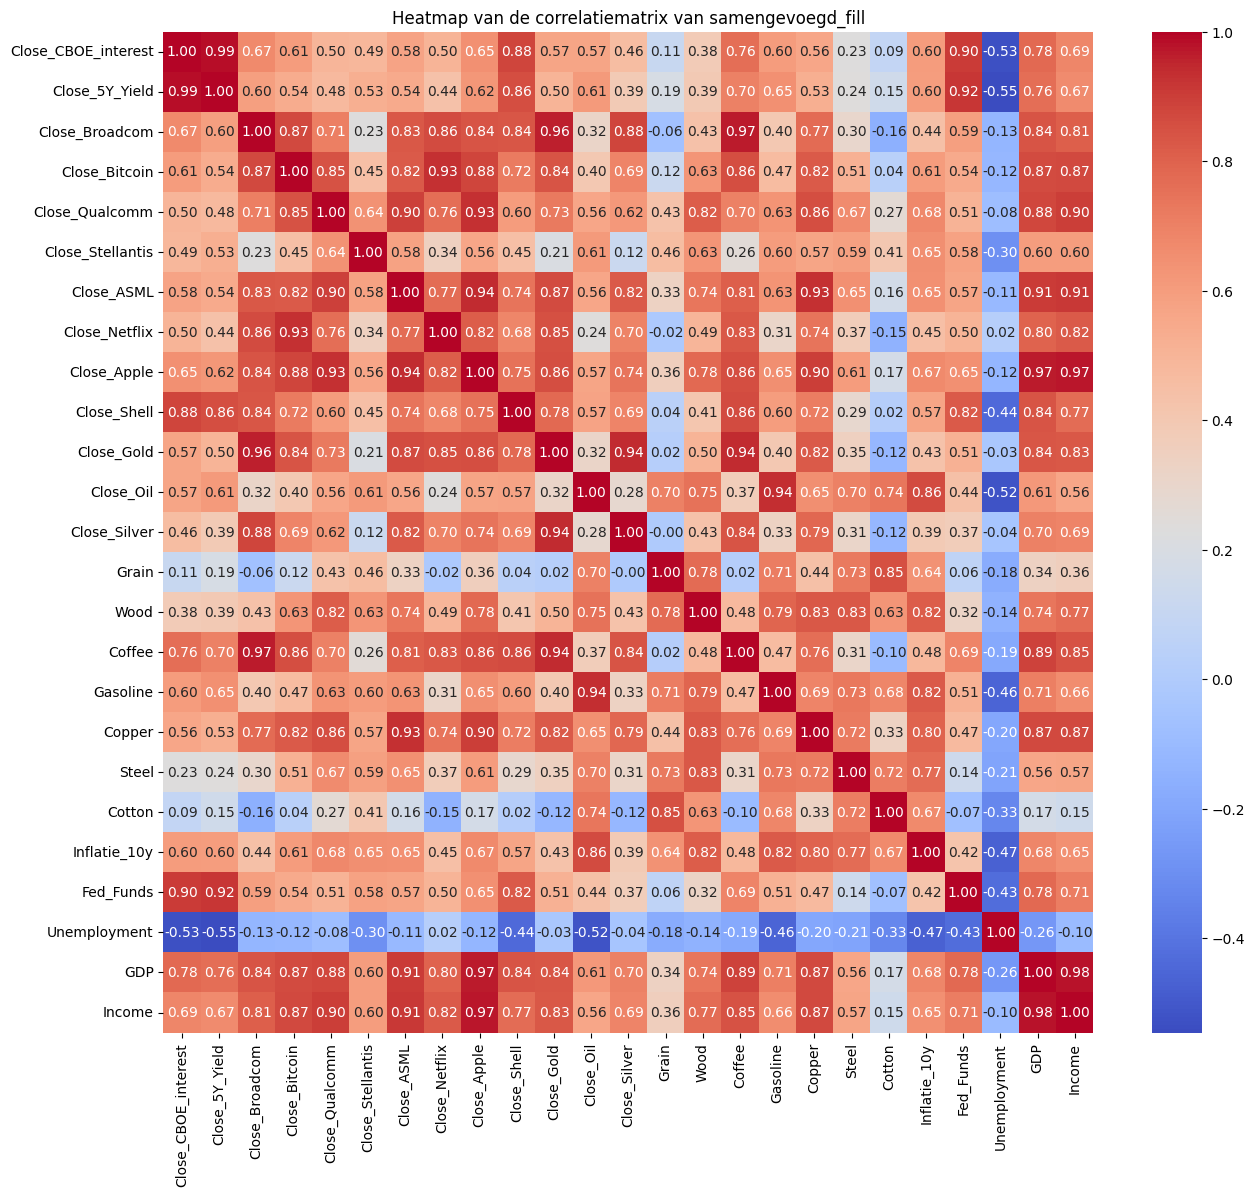

In [ ]:
plt.figure(figsize=(15, 13))
sns.heatmap(samengevoegd_fil.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap van de correlatiematrix van samengevoegd_fill')
plt.show()

Alleen de data geselecteerd die nodig is voor de onderzoeksvragen

In [ ]:
data = samengevoegd_fil.loc[:, ["GDP", "Income", "Coffee", "Gasoline", "Copper", "Close_Broadcom", "Close_Oil", "Close_Gold", "Close_ASML", "Close_Shell", "Close_Apple"]]
data = data.dropna()
data.head()


,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
2016-01-01,18525.933,15695.5,201.9,2.034,4471.7875,11.072823,37.040001,1060.300049,80.000687,27.336700,23.688847
2016-01-02,18525.933,15695.5,201.9,2.034,4471.7875,11.072823,37.040001,1060.300049,80.000687,27.336700,23.688847
2016-01-03,18525.933,15695.5,201.9,2.034,4471.7875,11.072823,37.040001,1060.300049,80.000687,27.336700,23.688847
2016-01-04,18525.933,15695.5,201.9,2.028,4471.7875,10.853882,36.759998,1075.099976,78.675888,27.360580,23.709110
2016-01-05,18525.933,15695.5,201.9,2.028,4471.7875,10.490763,35.970001,1078.400024,77.882812,27.229231,23.114969


##Dagrendement berekenen

Hier worden de koersen omgezet worden naar dagrendementen

In [ ]:
dag_rendement = data.pct_change()
dag_rendement = dag_rendement.dropna()
dag_rendement

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
2016-01-02,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-03,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-04,0.0,0.0,0.0,-0.00295,0.0,-0.019773,-0.007559,0.013958,-0.016560,0.000874,0.000855
2016-01-05,0.0,0.0,0.0,0.00000,0.0,-0.033455,-0.021491,0.003070,-0.010080,-0.004801,-0.025060
2016-01-06,0.0,0.0,0.0,0.00000,0.0,-0.030759,-0.055602,0.012519,-0.020944,-0.034861,-0.019570
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,0.0,0.0,0.0,0.00000,0.0,-0.001037,0.002595,-0.004141,0.025691,-0.005094,0.012558
2026-05-23,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-05-24,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-05-25,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#Lesweek 2


##.Describe
We gaan alle statistische maatstaven van de 3 portfolio's berekenen en uitleggen

In [ ]:
dag_rendement.describe()

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
count,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000,3798.000000
mean,0.000146,0.000153,0.000160,0.000238,0.000306,0.001167,-0.000444,0.000419,0.000994,0.000429,0.000791
std,0.002535,0.005008,0.003122,0.007725,0.008433,0.020391,0.059002,0.008636,0.019965,0.015794,0.015092
min,-0.082430,-0.128901,-0.019608,-0.056940,-0.167933,-0.199129,-3.059661,-0.113662,-0.173492,-0.171722,-0.128647
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004285,-0.004847,-0.001718,-0.004588,-0.003274,-0.002893
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.007034,0.008178,0.003285,0.007674,0.005247,0.005491
max,0.087490,0.207846,0.099238,0.161526,0.152110,0.244326,0.376623,0.060833,0.154341,0.196795,0.153289


Hier laten we de 2 laagste waardes van Olie vallen want dit zijn de meest extreme waardes in de dataset

In [ ]:
lowest_oil_values = dag_rendement['Close_Oil'].nsmallest(2)
print("Lowest oil values:\n", lowest_oil_values)

# Drop the rows corresponding to these lowest values from dag_rendement
dag_rendement = dag_rendement.drop(lowest_oil_values.index)
print("\ndag_rendement after dropping the rows (first 5 rows):\n", dag_rendement.head())

Lowest oil values:
 2020-04-20   -3.059661
2020-04-21   -1.266011
Freq: D, Name: Close_Oil, dtype: float64

dag_rendement after dropping the rows (first 5 rows):
             GDP  Income  Coffee  Gasoline  Copper  Close_Broadcom  Close_Oil  \
2016-01-02  0.0     0.0     0.0   0.00000     0.0        0.000000   0.000000   
2016-01-03  0.0     0.0     0.0   0.00000     0.0        0.000000   0.000000   
2016-01-04  0.0     0.0     0.0  -0.00295     0.0       -0.019773  -0.007559   
2016-01-05  0.0     0.0     0.0   0.00000     0.0       -0.033455  -0.021491   
2016-01-06  0.0     0.0     0.0   0.00000     0.0       -0.030759  -0.055602   

            Close_Gold  Close_ASML  Close_Shell  Close_Apple  
2016-01-02    0.000000    0.000000     0.000000     0.000000  
2016-01-03    0.000000    0.000000     0.000000     0.000000  
2016-01-04    0.013958   -0.016560     0.000874     0.000855  
2016-01-05    0.003070   -0.010080    -0.004801    -0.025060  
2016-01-06    0.012519   -0.020944    -0.

In [ ]:
dag_rendement.describe()

,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
count,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000,3796.000000
mean,0.000146,0.000153,0.000160,0.000244,0.000307,0.001186,0.000695,0.000421,0.001008,0.000448,0.000805
std,0.002536,0.005009,0.003123,0.007718,0.008435,0.020380,0.024365,0.008634,0.019960,0.015769,0.015084
min,-0.082430,-0.128901,-0.019608,-0.056940,-0.167933,-0.199129,-0.245882,-0.113662,-0.173492,-0.171722,-0.128647
25%,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004265,-0.004770,-0.001714,-0.004526,-0.003250,-0.002851
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.007041,0.008183,0.003284,0.007678,0.005252,0.005492
max,0.087490,0.207846,0.099238,0.161526,0.152110,0.244326,0.376623,0.060833,0.154341,0.196795,0.153289


De waardes van GDP, Income, Copper en Coffee zijn niet goed uit te leggen met deze methode door het gebruik van Forward fill, hierdoor zijn bijna alle veranderingen 0

##Mediaan en Modus

In [ ]:
medianen_alle_kolommen = data.median(numeric_only=True)
print("\nMedianen voor alle numerieke kolommen:")
print(medianen_alle_kolommen)


Medianen voor alle numerieke kolommen:
GDP               22680.693000
Income            21008.400000
Coffee              198.578000
Gasoline              2.865000
Copper             7772.238095
Close_Broadcom       41.371113
Close_Oil            63.580002
Close_Gold         1775.800049
Close_ASML          460.171570
Close_Shell          45.561344
Close_Apple         124.254234
dtype: float64


De berekingen van de mediaan is op basis van de reële koers gedaan.



In [ ]:
modi_alle_kolommen = dag_rendement.mode(numeric_only=True)
print("\nModi voor alle numerieke kolommen:")
display(modi_alle_kolommen)


Modi voor alle numerieke kolommen:


,GDP,Income,Coffee,Gasoline,Copper,Close_Broadcom,Close_Oil,Close_Gold,Close_ASML,Close_Shell,Close_Apple
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


De modi zijn berekend op basis van het dagrendement, door de Forward fill zijn alle waardes nul.

##Boxplot

<Axes: >

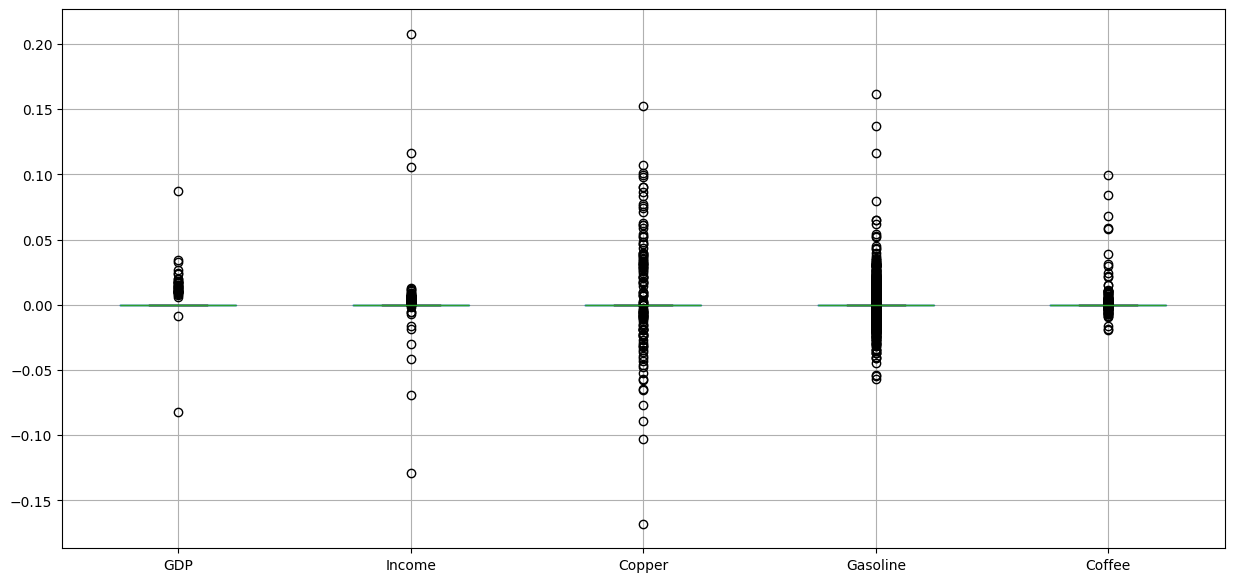

In [ ]:
dag_rendement.boxplot(column=["GDP", "Income","Copper","Gasoline","Coffee"], figsize=(15, 7))

Deze boxplots zijn berekend door: <br> min = Q1 - ((Q3 - Q1) * 1,5)
<br>max = Q3 + ((Q3 - Q1) * 1,5)

Alles is tussen de 25% en 75% op 0, dit komt door Forward fill. Income heeft de grootste uitschieters. Copper is het meest volatiel, dit is te zien aan de constante uitwijkingen.



<Axes: >

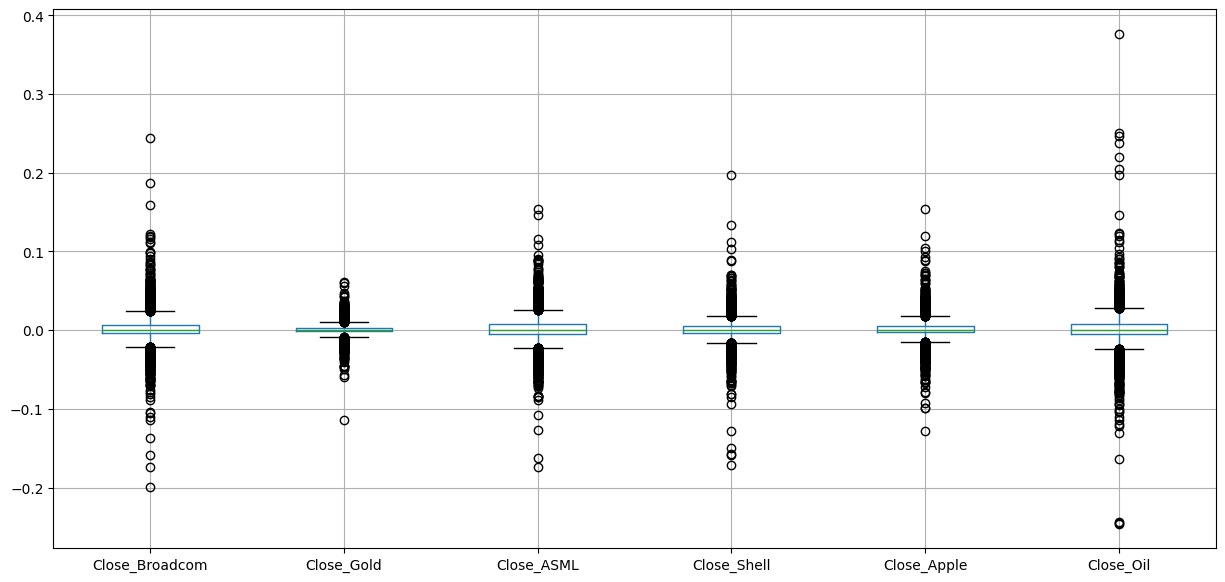

In [ ]:
dag_rendement.boxplot(column=["Close_Broadcom","Close_Gold","Close_ASML","Close_Shell","Close_Apple","Close_Oil"], figsize=(15, 7))

De 2 laagste waardes van Olie waren laten vallen omdat het de boxplot onleesbaar maakte.

Alle assets hebben een mediaan rond nul (normaal voor dagrendementen), maar verschillen sterk in volatiliteit. Oil en Broadcom hebben de grootste spreiding, Gold is het stabielst.

##Histogram

Een histogram is een grafische weergave in data-analyse die de frequentieverdeling van numerieke gegevens toont door middel van staven.

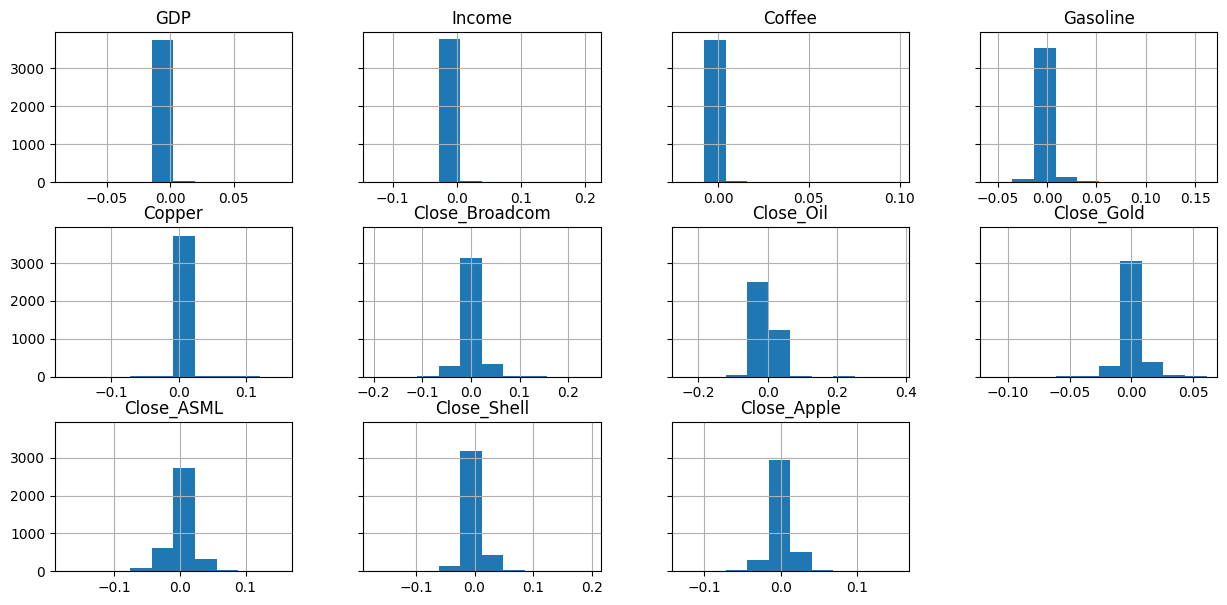

In [ ]:
dag_rendement.hist(layout=(3, 4), figsize=(15, 7), sharey=True)
plt.show()

Alle verdelingen zijn smal en gecentreerd rond nul, met dikkere staarten dan een normale verdeling. Close_Oil en Close_Broadcom zijn het meest volatiel. Close_Gold en de macro-economische indicatoren het meest stabiel.

##Scheefheid

Dit geeft aan of de verdeling symmetrisch, links- of rechtsscheef is.

Als skewness = 0: verdeling is symmetrisch<br>
Als skewness < 0: verdeling is linksscheef, de staarten aan de linkerkant zijn groter / langer dan bij een symmetrische verdeling<br>
Als skewness > 0: verdeling is rechtsscheef, de staarten aan de rechterkant zijn groter / langer dan bij een symmetrische verdeling

In [ ]:
dag_rendement.skew()

,0
GDP,4.999743
Income,19.126660
Coffee,20.904554
Gasoline,5.626904
Copper,2.499193
Close_Broadcom,0.439198
Close_Oil,1.251689
Close_Gold,-0.676151
Close_ASML,-0.099757
Close_Shell,-0.453454


Coffee en Income zijn het scheefst. Alle verdelingen zijn asymmetrisch.

##Kurtosis
Dit geeft aan of de verdeling 'spits' (met veel uitschieters) of 'vlak' (met weinig uitschieters) is.
<p>
Als kurtosis = 0: verdeling is symmetrisch<br>
Als kurtosis =< 3: verdeling heeft weinig uitschieters<br>
Als kurtosis > 3: verdeling heeft veel uitschieters<br>

In [ ]:
dag_rendement.kurtosis()

,0
GDP,697.509734
Income,1032.956711
Coffee,539.857994
Gasoline,104.637959
Copper,129.660599
Close_Broadcom,17.276715
Close_Oil,37.727880
Close_Gold,14.558950
Close_ASML,7.822598
Close_Shell,24.053653


Doordat de gebruikte data over tien jaar is en een koers, krijg je uitschieters.

##Heatmap van de relevante data

Met deze code kan je de correlatie berekenen en in een matrix hittematrix laten zien.

Als de correlatiecoëfficiënt ligt tussen de -0,3 en 0,3 is er geen sprake van correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,3 -0,6) of (0,3 0,6) is er sprake van zwakke correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,6 -0,9) of (0,6 0,9) is er sprake van matige correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,9 -1) of (0,9 1) is er sprake van sterke correlatie.

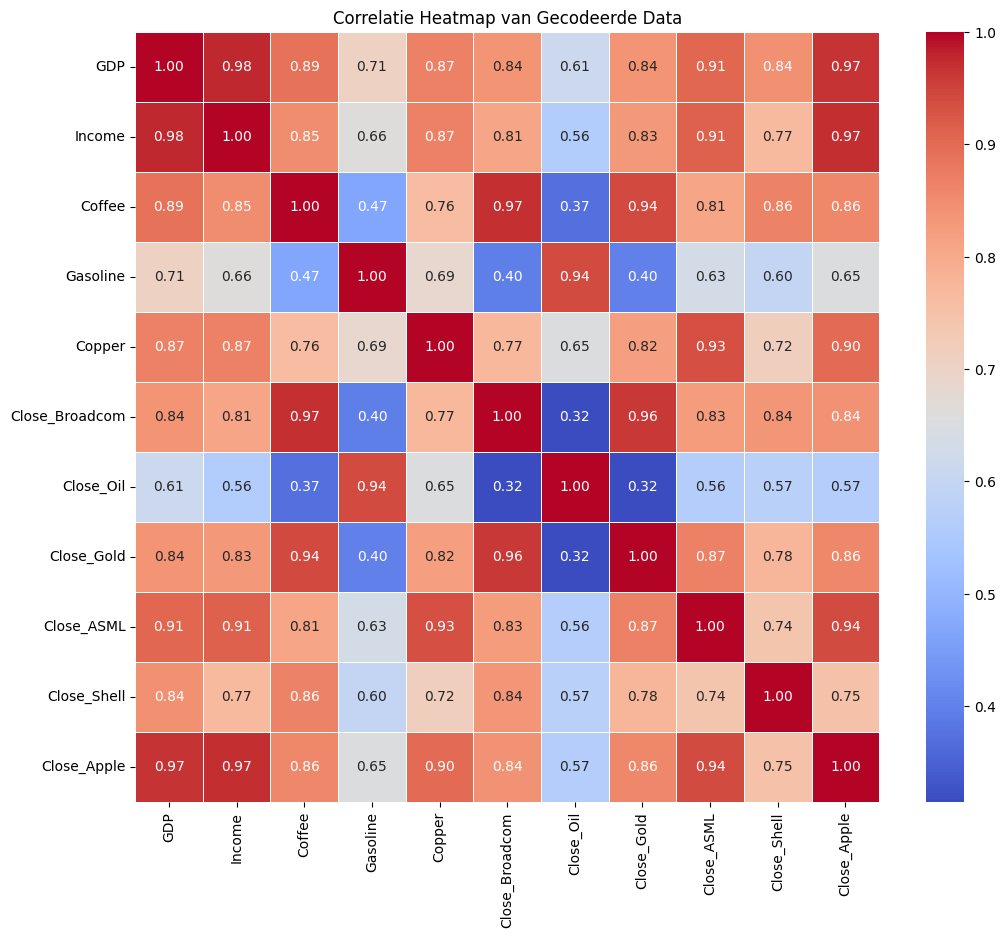

In [ ]:
correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlatie Heatmap van Gecodeerde Data')
plt.show()

Wij hebben gekozen om de rouwe data van de koers te gebruiken in plaats van de data die berekend is bij het dagrendement, dit is besloten omdat de vele 0 waardes dit door Forward Fill geintroduceerd zijn de heatmap van dagrendement onbetrouwbaar maakt.<p>
In deze heatmap is dezelfde informatie gezien als in de eerdere heatmap maar het is hier beter af te lezen, er zijn een heleboel correlaties sinds dit is ook de reden voor het kiezen van deze variabelen.

## Bubble Charts

Deze bubble charts tonen de relatie tussen drie variabelen, waarbij de grootte van de cirkel een extra dimensie vertegenwoordigt. De schaal van de groottevariabele is aangepast voor betere visualisatie.

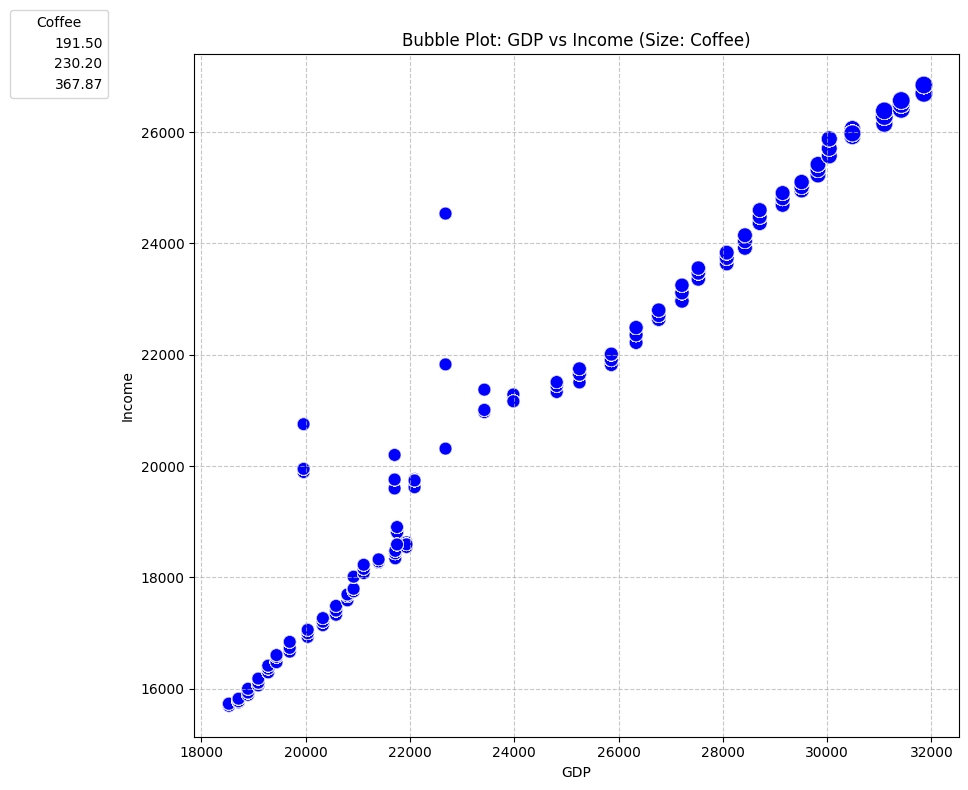

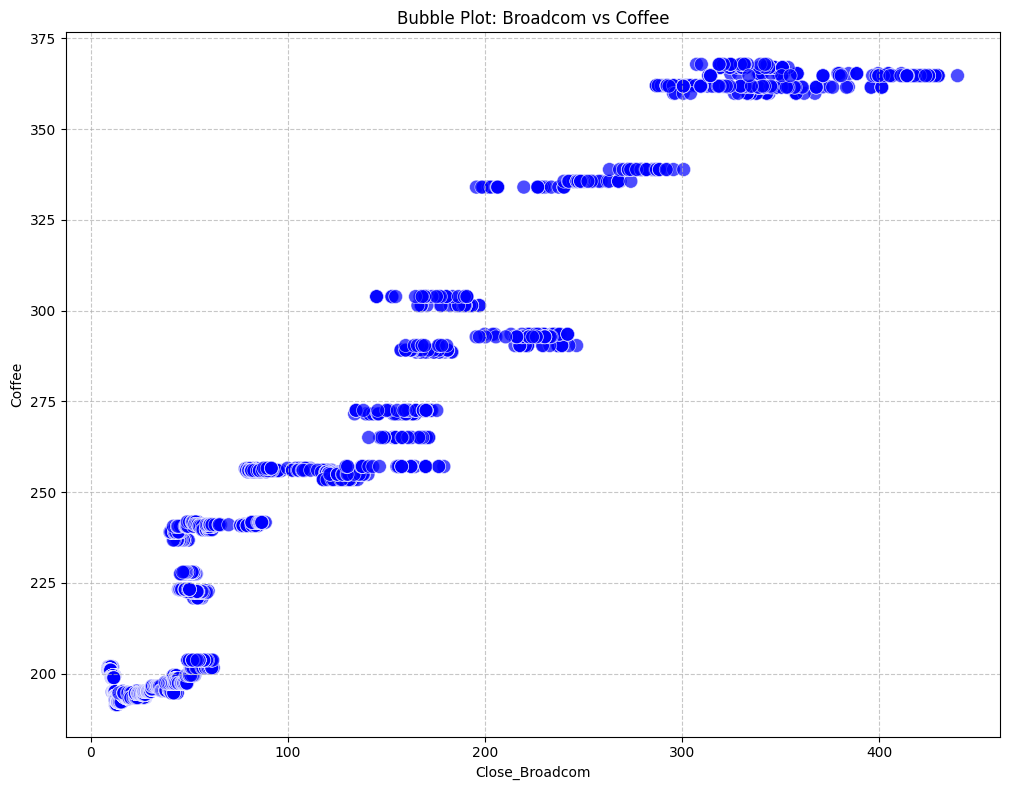

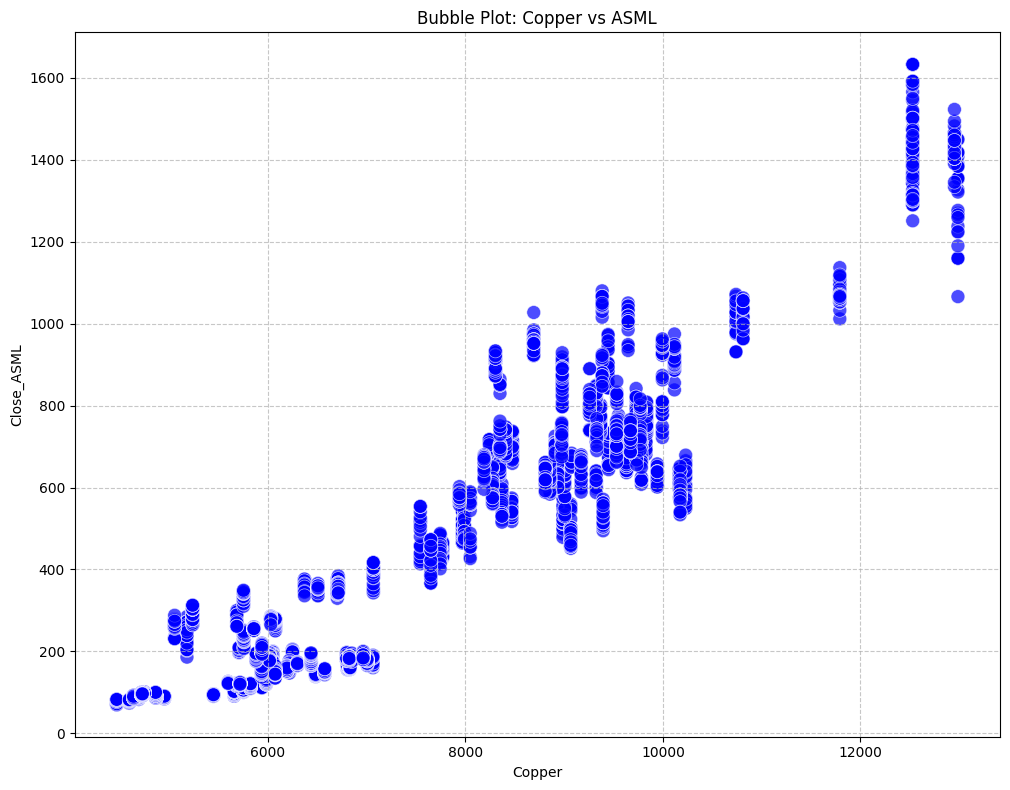

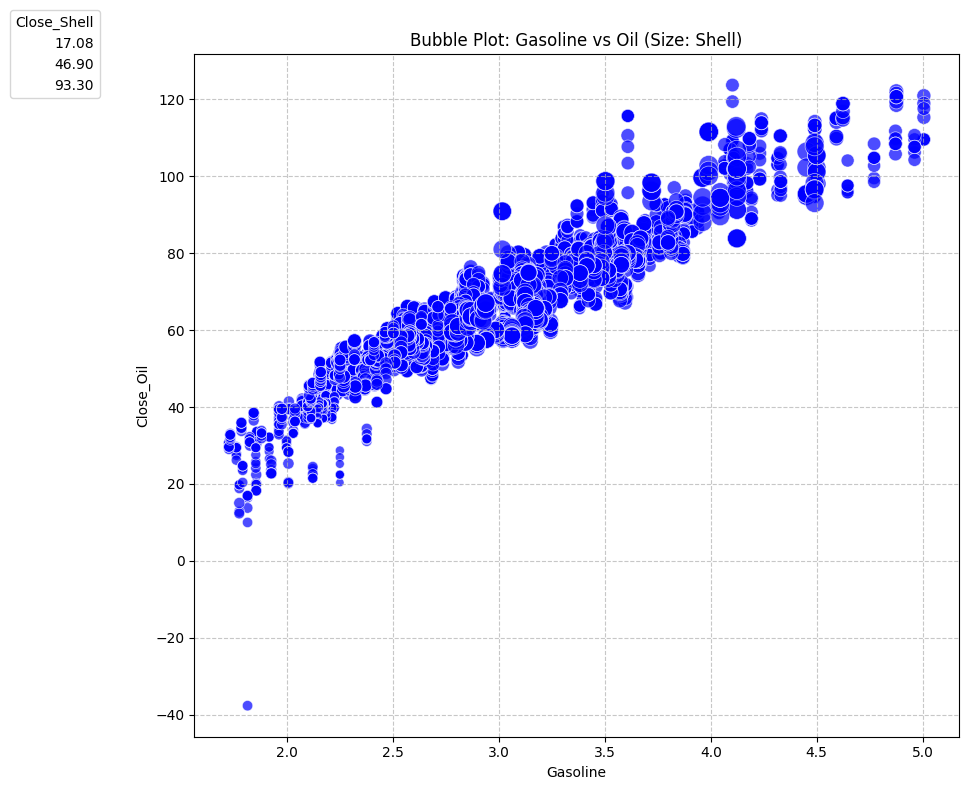

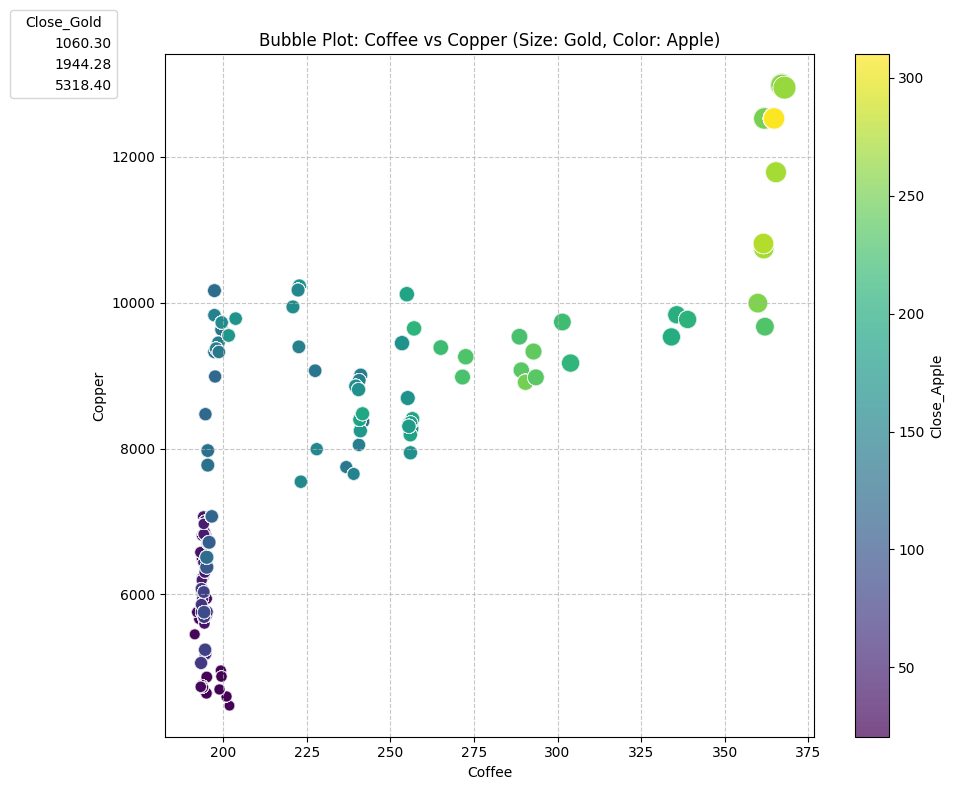

In [ ]:
def create_bubble_plot(df, x_col, y_col, size_col=None, color_col=None, title=''):
    plt.figure(figsize=(12, 8))

    # Handle size column
    if size_col and size_col in df.columns:
        sizes = df[size_col] / df[size_col].mean() * 100  # Adjust scaling factor as needed
        size_args = {'s': sizes}
    else:
        sizes = pd.Series([100] * len(df)) # Default fixed size
        size_args = {'s': sizes}

    # Handle color column
    if color_col and color_col in df.columns:
        color_args = {'c': df[color_col], 'cmap': 'viridis'}
    else:
        color_args = {'c': 'blue'}

    scatter = plt.scatter(df[x_col], df[y_col], **size_args, **color_args, alpha=0.7, edgecolors='w', linewidth=0.5)

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Create a legend for sizes if size_col is provided
    if size_col and size_col in df.columns:
        handles, labels = scatter.legend_elements(prop="sizes", alpha=0., num=[sizes.min(), sizes.mean(), sizes.max()])
        plt.legend(handles, [f'{s_val:.2f}' for s_val in [df[size_col].min(), df[size_col].mean(), df[size_col].max()]], title=size_col, loc='center left', bbox_to_anchor=(-0.25, 1))

    # Add a colorbar for the color variable if color_col is provided
    if color_col and color_col in df.columns:
        cbar = plt.colorbar(scatter, ax=plt.gca(), orientation='vertical')
        cbar.set_label(color_col)

    plt.tight_layout(rect=[0.15, 0, 1, 1])  # Adjust layout to make space for the legend on the left and colorbar on the right
    plt.show()

# Vraag 1: Wat is het verband tussen GDP (x-as), Income (y-as), Coffee (grootte) en Close_Gold (kleur)?
create_bubble_plot(data, 'GDP', 'Income', 'Coffee', None, 'Bubble Plot: GDP vs Income (Size: Coffee)')

# Vraag 2: Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?
create_bubble_plot(data, 'Close_Broadcom', 'Coffee', None, None, 'Bubble Plot: Broadcom vs Coffee')

# Vraag 3: Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?
create_bubble_plot(data, 'Copper', 'Close_ASML', None, None, 'Bubble Plot: Copper vs ASML')

# Vraag 4: Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?
create_bubble_plot(data, 'Gasoline', 'Close_Oil', 'Close_Shell', None, 'Bubble Plot: Gasoline vs Oil (Size: Shell)')

# Vraag 5: Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?
create_bubble_plot(data, 'Coffee', 'Copper', 'Close_Gold', 'Close_Apple', 'Bubble Plot: Coffee vs Copper (Size: Gold, Color: Apple)')

1.	Wat is het verband tussen GDP (x1), Income (Persoonlijk inkomen) (x2) en Coffee (y1)? <br>
Hoe hoger het inkomen en de GDP, des te hoger de koers van Coffee.
<p>

2.	Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?<br>
Het is niet een stabiel verband maar wel een relatief positief lineaire verband.
<p>

3.	Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?<br>
Het verband is lineaire verdeeld, maar er is in het midden van de grafiek wel een ophoping.
<p>

4.	Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?<br>
Het verband is lineaire verdeeld, maar begint als de koers van Close_Oil hoog is.
 <p>

5.	Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?<br>
Hoe hoger de Coffee-koers, hoe groter en geler de bubbles, dit wijst op een positief verband tussen Coffee, Gold én Apple. Copper lijkt minder een verband te hebben.

#Lesweek 3

##Enkelvoudige en meervoudige regressie

Enkelvoudige regressie onderzoekt het verband tussen één verklarende variabele en een uitkomstvariabele, terwijl meervoudige regressie het effect van meerdere verklarende variabelen tegelijk op één uitkomstvariabele onderzoekt.

Er zijn een aantal waarde die belangrijk zijn, namelijk: <br>
**P (P>|t|):** De p-waarde geeft aan of het effect van een variabele statistisch significant is, dus of het verband waarschijnlijk geen toeval is. Meestal geldt: p < 0,05 betekent een significant effect.<br>
**R-kwadraat (R-squared):** R-kwadraat laat zien hoeveel van de variatie in de uitkomstvariabele door het regressiemodel wordt verklaard. Hoe hoger de waarde (tussen 0 en 1), hoe beter het model de data verklaart.<br>
**Coëfficiënt (coef):** De coëfficiënt geeft aan hoe sterk en in welke richting een variabele invloed heeft op de uitkomstvariabele. Een positieve waarde betekent dat de uitkomst stijgt bij een toename van de variabele, een negatieve waarde betekent dat deze daalt.<p>

Als de correlatiecoëfficiënt ligt tussen de -0,3 en 0,3 is er geen sprake van correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,3 -0,6) of (0,3 0,6) is er sprake van zwakke correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,6 -0,9) of (0,6 0,9) is er sprake van matige correlatie.<br>
Als de correlatiecoëfficiënt ligt tussen de (-0,9 -1) of (0,9 1) is er sprake van sterke correlatie.

###Onderzoeksvraag 1 regressie

Wat is het verband tussen GDP (x1), Income (Persoonlijk inkomen) (x2) en Coffee (y1)?


In [ ]:
X = data[["GDP", "Income"]]
y = data[["Coffee"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Coffee   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     7483.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:40:01   Log-Likelihood:                -17382.
No. Observations:                3799   AIC:                         3.477e+04
Df Residuals:                    3796   BIC:                         3.479e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.4085      2.278    -11.590      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.3 en kleiner dan 0.8, dus er is een matige correlatie. <br>
De coefficient geeft hier aan dat als het GDP met een dollar stijgt, de Coffee koers met 0,0155 dollar stijgt. Als het Income met een dollar stijgt dan daalt de Coffee koers met 0,0059 dollar.<p>
Door het verband tussen de onafhankelijke variabelen, die te zien is in de heatmap, is er niet een realistische conclusie te trekken uit de regressie.

###Onderzoeksvraag 2 regressie

Wat is het verband van Close_Broadcom (x3) op de Coffee(y1)?

In [ ]:
X = data[["Close_Broadcom"]]
y = data[["Coffee"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Coffee   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                 5.917e+04
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:40:01   Log-Likelihood:                -15082.
No. Observations:                3799   AIC:                         3.017e+04
Df Residuals:                    3797   BIC:                         3.018e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            188.2911      0.270    697.

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie.<br>
De coefficient geeft hier aan dat per dollar stijging van Close_Broadcom de Coffee prijs met 0,528 dollar stijgt.<p>
Er is geen logisch verband te vinden tussen Broadcom en Coffee, dus er is geen conlusie te trekken uit de regressie.

###Onderzoeksvraag 3 regressie

Hoeveel invloed heeft de Copper (x4) op de koers van Close_ASML (y2)?

In [ ]:
X = data[["Copper"]]
y = data[["Close_ASML"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:             Close_ASML   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                 2.559e+04
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:40:01   Log-Likelihood:                -23612.
No. Observations:                3799   AIC:                         4.723e+04
Df Residuals:                    3797   BIC:                         4.724e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -727.7605      7.817    -93.103      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Copper de Close_ASML stijgt met 0,154 dollar.<p>
Als de koers van ASML stijgt, geeft dit aan dat de vraag naar chips stijgt. Door de vele koper die wordt gebruikt in chips, stijgt die koers ook.

###Onderzoeksvraag 4 regressie

Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?

In [ ]:
X = data[["Gasoline", "Close_Oil"]]
y = data[["Close_Shell"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:            Close_Shell   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     1060.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:40:01   Log-Likelihood:                -14762.
No. Observations:                3799   AIC:                         2.953e+04
Df Residuals:                    3796   BIC:                         2.955e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1249      1.011      7.048      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.3 en kleiner dan 0.8, dus er is een matige correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Gasoline de koers van Close_Shell stijgt met 11,0131 dollar. Als Close_oil met een dollar stijgt dan stijgt de koers van Close_shel met 0,104 dollar.<p>
De koers van Close_Shell reageert niet op actuele olie en benzine prijs, maar het verandert het op basis van verwachte lange termijn koers van Gasoline en Close_Oil. Bij lesweek 4 gaan we kijken naar tijdsvertragingen.

###Onderzoeksvraag 5 regressie

Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?

In [ ]:
X = data[["Coffee", "Copper", "Close_Gold"]]
y = data[["Close_Apple"]]

X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:            Close_Apple   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     9190.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:40:01   Log-Likelihood:                -17914.
No. Observations:                3799   AIC:                         3.584e+04
Df Residuals:                    3795   BIC:                         3.586e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -212.8127      3.631    -58.613      0.0

P is lager dan 0.05, er is dus een significant verband. <br>
R-squared is groter dan 0.8, dus er is een sterke correlatie. <br>
De coefficient geeft hier aan dat per dollar stijging van Close_Apple de Coffee stijgt met 0,7357 dollar, de Copper stijgt met 0,0235 dollar en de Close_Gold verandert met -0,0095 dollar.<p>
Als de koers van Close_Apple het goed doet, geeft dit aan dat er een hoog conjuctuur is, omdat Apple een luxe merk is. Apple gebruikt veel chips en daardoor stijgt dan ook de Copper prijs. Coffee is i.d. als onderzoeksvraag 1. Als er een hoog conjuctuur is in USA dan is historisch de goud koers minder sterk.

#Lesweek 4

##4a Seasonal decomposing

###Shell

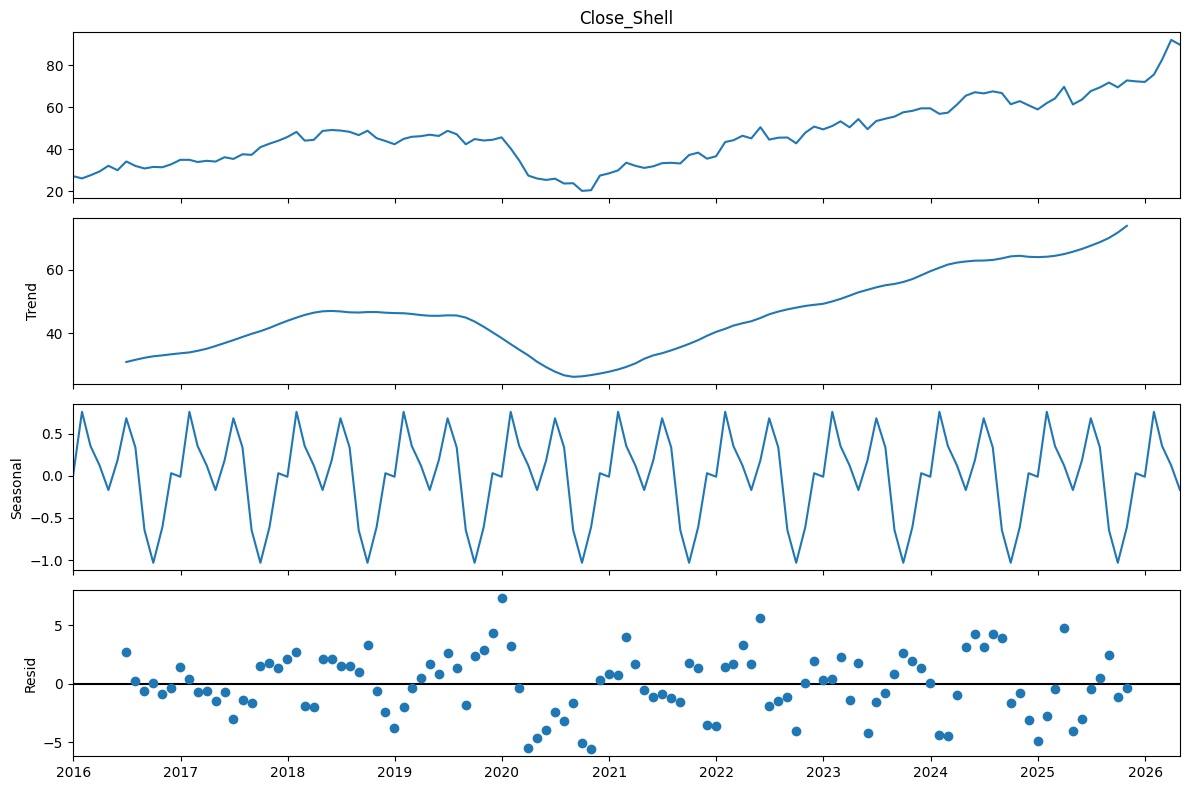

In [ ]:
shell_monthly = samengevoegd_fil['Close_Shell'].asfreq('ME', method='pad')
decompose_result_Shell = seasonal_decompose(shell_monthly.dropna(), period=12)

df_trend = decompose_result_Shell.trend
df_season = decompose_result_Shell.seasonal
df_residual = decompose_result_Shell.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_Shell.plot()

De trend in de koers van Shell gedurende de periode januari 2016- vandaag is positief.<br>
De seizoenscomponent vertoont een duidelijk terugkerend patroon met afwisselend positieve en negatieve waarden. Dit wijst juist op een stabiele seizoensinvloed en niet op een random walk. Bij een random walk zou geen regelmatig herhalend patroon zichtbaar zijn.<br>
In de residugrafiek zijn de afwijkingen rond de trend en seizoenscomponent zichtbaar. Vanaf ongeveer 2020 lijken de uitslagen groter te worden dan in de beginperiode (2016–2018), wat kan wijzen op een toename van de volatiliteit of onzekerheid.

###Olie

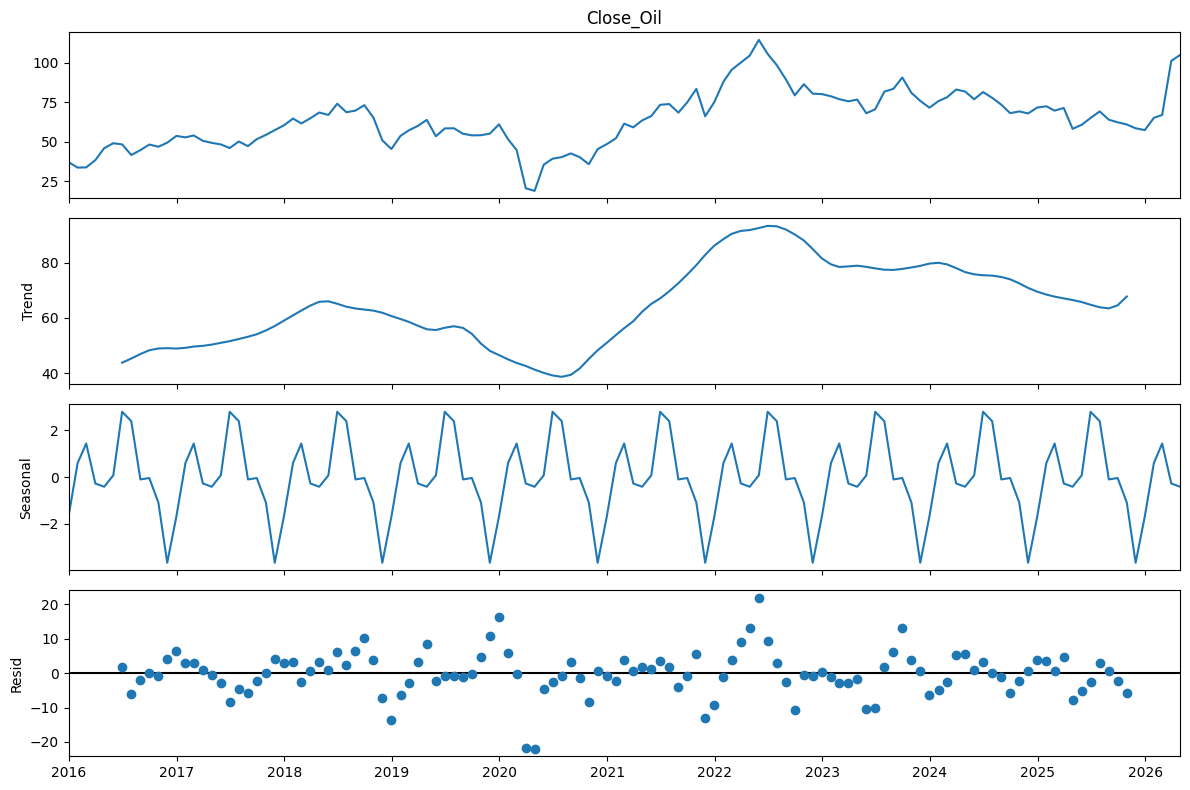

In [ ]:
oil_monthly = samengevoegd_fil['Close_Oil'].asfreq('ME', method='pad')
decompose_result_Oil = seasonal_decompose(oil_monthly.dropna(), period=12)

df_trend_oil = decompose_result_Oil.trend
df_season_oil = decompose_result_Oil.seasonal
df_residual_oil = decompose_result_Oil.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_Oil.plot()

De trend in de olieprijs gedurende de periode 2016–2026 is wisselend. Er is een stijgende lijn zichtbaar tot ongeveer 2022, waarna de trend licht daalt, met een opvallende dip rond 2020 als gevolg van de COVID-19-crisis. <br>
De seizoensinvloed op de olieprijs is regelmatig afwisselend positief en negatief, dat duidt op een voorspelbare cyclische component in de prijs. <br>
In de grafiek van de residuen is te zien dat de afwijkingen rond 2020 en 2022 opvallend groot zijn. Er is meer onzekerheid ten aanzien van de olieprijs in die jaren dan in de periode 2016–2019.

###GDP

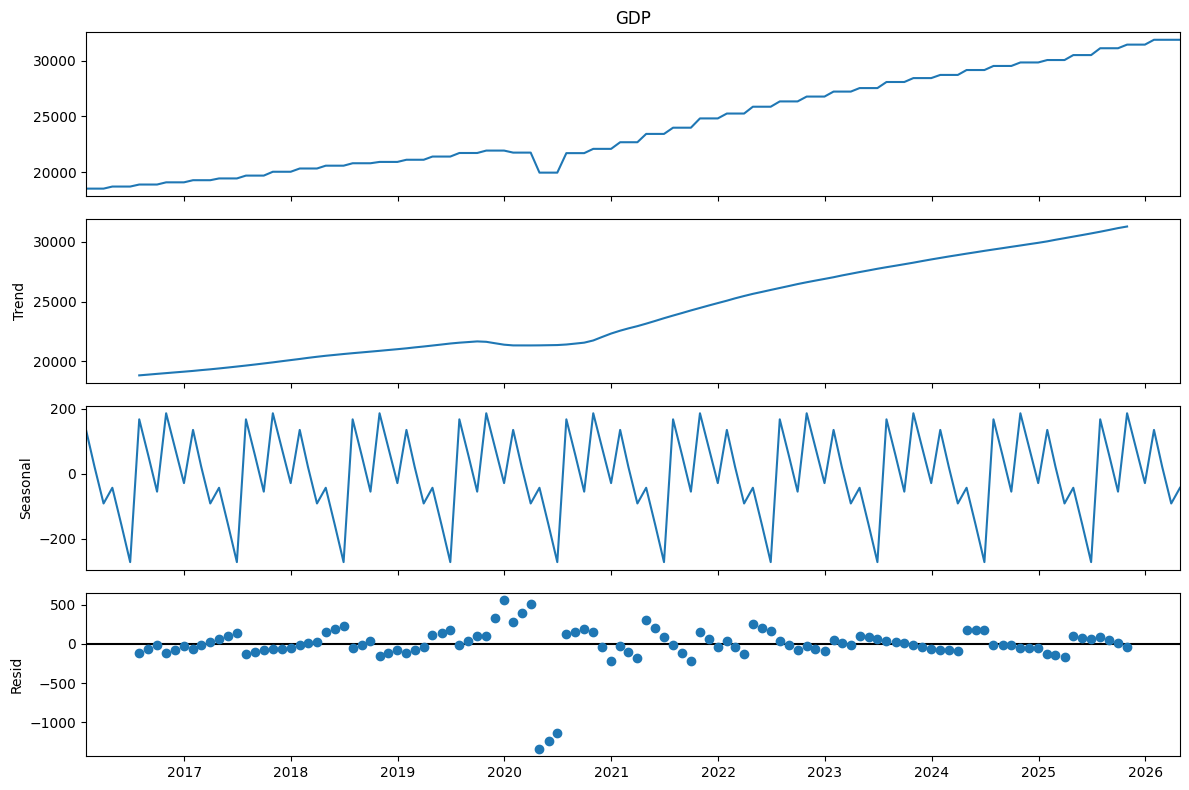

In [ ]:
gdp_monthly = samengevoegd_fil['GDP'].asfreq('ME', method='pad')
decompose_result_GDP = seasonal_decompose(gdp_monthly.dropna(), period=12)

df_trend_gdp = decompose_result_GDP.trend
df_season_gdp = decompose_result_GDP.seasonal
df_residual_gdp = decompose_result_GDP.resid

plt.rcParams['figure.figsize'] = (12, 8)
fig = decompose_result_GDP.plot()

De tijdreeksanalyse van het GDP laat een duidelijke stijgende trend zien van 2016 tot 2025. Rond 2020 is een sterke daling zichtbaar, waarna het GDP zich snel herstelt en verder groeit. De seizoenscomponent toont terugkerende jaarlijkse schommelingen. De residuen liggen meestal rond de nullijn, behalve in 2020 waar grote afwijkingen zichtbaar zijn. <br>

###tabular presentation year-end close composition

In [ ]:
def print_time_series_table(data_dict):
    """
    Print time series data in a tabular format.

    Parameters:
    data_dict (dict): Dictionary with row labels as keys and series of values as values,
                      including a 'dates' key for the column headers
    """
    # Print each row of data
    for label, values in data_dict.items():
        print(f"{label:20}", end='')
        # Format each value
        for value in values:
            if isinstance(value, dt.datetime):  # Check if value is datetime
                print(f"{value.strftime('%d-%m-%Y'):>20}", end='')
            else:  # Treat as float
                print(f"{value:>20.3f}", end='')
        print()

year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

data_to_print = {
    'Date': year_end_dates,
    'Close_Shell ($)': samengevoegd_fil['Close_Shell'].loc[year_end_dates],
    'Trend ($)': decompose_result_Shell.trend.loc[year_end_dates],
    'Seasonality ($)': decompose_result_Shell.seasonal.loc[year_end_dates],
    'Residual ($)': decompose_result_Shell.resid.loc[year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2015          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Close_Shell ($)                   27.337              35.062              45.939              42.488              45.763              28.630              36.768              49.567              59.576              59.056              72.146
Trend ($)                            nan              33.625              43.884              46.319              38.439              27.815              40.388              49.251              59.529              63.977                 nan
Seasonality ($)                   -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012              -0.012
Residual ($)                        

In [ ]:
year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

data_to_print = {
    'Date': year_end_dates,
    'Close_Oil ($)': samengevoegd_fil['Close_Oil'].loc[year_end_dates],
    'Trend ($)': decompose_result_Oil.trend.loc[year_end_dates],
    'Seasonality ($)': decompose_result_Oil.seasonal.loc[year_end_dates],
    'Residual ($)': decompose_result_Oil.resid.loc[year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2015          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Close_Oil ($)                     37.040              53.720              60.420              45.410              61.060              48.520              75.210              80.260              71.650              71.720              57.420
Trend ($)                            nan              48.901              59.024              60.694              46.513              50.990              86.297              81.638              79.762              69.559                 nan
Seasonality ($)                   -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693              -1.693
Residual ($)                        

In [ ]:
year_end_dates = [dt.datetime(year, 12, 31) for year in range(samengevoegd_fil.index.min().year, end.year)]

# Filter year_end_dates to only include dates present in decompose_result_GDP.trend
# This is necessary because seasonal_decompose introduces NaNs at the beginning/end
# and dropna() before seasonal_decompose might further alter the start date.
# The intersection will ensure only valid dates are used for indexing.
valid_year_end_dates = decompose_result_GDP.trend.index.intersection(year_end_dates)

data_to_print = {
    'Date': valid_year_end_dates,
    'Income ($)': samengevoegd_fil['GDP'].loc[valid_year_end_dates],
    'Trend ($)': decompose_result_GDP.trend.loc[valid_year_end_dates],
    'Seasonality ($)': decompose_result_GDP.seasonal.loc[valid_year_end_dates],
    'Residual ($)': decompose_result_GDP.resid.loc[valid_year_end_dates]
}

print_time_series_table(data_to_print)

Date                          31-12-2016          31-12-2017          31-12-2018          31-12-2019          31-12-2020          31-12-2021          31-12-2022          31-12-2023          31-12-2024          31-12-2025
Income ($)                     19089.379           20037.088           20917.867           21933.217           22087.160           24813.600           26770.514           28424.722           29825.182           31422.526
Trend ($)                      19144.897           20112.192           21022.491           21399.965           22330.066           24875.430           26893.798           28521.319           29910.393                 nan
Seasonality ($)                  -28.675             -28.675             -28.675             -28.675             -28.675             -28.675             -28.675             -28.675             -28.675             -28.675
Residual ($)                     -26.843             -46.429             -75.949             561.928            -214

###Seizoensinvloed koers Shell?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van Shell. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [ ]:
seizoen_Shell = samengevoegd_fil['Close_Shell'].reset_index().reset_index()
seizoen_Shell['Month'] = pd.DatetimeIndex(seizoen_Shell['index']).month
seizoen_Shell = seizoen_Shell.rename(columns = {'level_0' : 'Time'})
seizoen_Shell

,Time,index,Close_Shell,Month
0,0,2015-12-25,NaN,12
1,1,2015-12-26,NaN,12
2,2,2015-12-27,NaN,12
3,3,2015-12-28,27.360580,12
4,4,2015-12-29,27.754597,12
...,...,...,...,...
3801,3801,2026-05-22,85.709999,5
3802,3802,2026-05-23,85.709999,5
3803,3803,2026-05-24,85.709999,5
3804,3804,2026-05-25,85.709999,5


In [ ]:
for i in range(1,12):
  seizoen_Shell["M" + str(i)] = np.where(seizoen_Shell["Month"] == i, 1,0)
seizoen_Shell

,Time,index,Close_Shell,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-12-25,NaN,12,0,0,0,0,0,0,0,0,0,0,0
1,1,2015-12-26,NaN,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-27,NaN,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-28,27.360580,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-29,27.754597,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,2026-05-22,85.709999,5,0,0,0,0,1,0,0,0,0,0,0
3802,3802,2026-05-23,85.709999,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-24,85.709999,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-25,85.709999,5,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
X_Shell = seizoen_Shell.copy()
X_Shell.drop(seizoen_Shell.columns[[1, 2, 3]], axis = 1, inplace= True)
X_Shell

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,0,0,0,0,1,0,0,0,0,0,0
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
y_Shell = seizoen_Shell[seizoen_Shell.columns[2]]
y_Shell

,Close_Shell
0,NaN
1,NaN
2,NaN
3,27.360580
4,27.754597
...,...
3801,85.709999
3802,85.709999
3803,85.709999
3804,85.709999


In [ ]:
mask = y_Shell.notna() & X_Shell.notna().all(axis=1)
reg = sm.OLS(y_Shell[mask], X_Shell[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:            Close_Shell   R-squared (uncentered):                   0.945
Model:                            OLS   Adj. R-squared (uncentered):              0.945
Method:                 Least Squares   F-statistic:                              5409.
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        13:40:03   Log-Likelihood:                         -14698.
No. Observations:                3803   AIC:                                  2.942e+04
Df Residuals:                    3791   BIC:                                  2.950e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M1, M6, M7, M8, M9, M10 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is klein maar positief: er is een lichte opwaartse trend in de koersdata van Shell.

###Seizoensinvloed koers Olie?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van Olie. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [ ]:
seizoen_Oil = samengevoegd_fil['Close_Oil'].reset_index().reset_index()
seizoen_Oil['Month'] = pd.DatetimeIndex(seizoen_Oil['index']).month
seizoen_Oil = seizoen_Oil.rename(columns = {'level_0' : 'Time'})
seizoen_Oil

,Time,index,Close_Oil,Month
0,0,2015-12-25,NaN,12
1,1,2015-12-26,NaN,12
2,2,2015-12-27,NaN,12
3,3,2015-12-28,36.810001,12
4,4,2015-12-29,37.869999,12
...,...,...,...,...
3801,3801,2026-05-22,96.599998,5
3802,3802,2026-05-23,96.599998,5
3803,3803,2026-05-24,96.599998,5
3804,3804,2026-05-25,96.599998,5


In [ ]:
for i in range(1,12):
  seizoen_Oil["M" + str(i)] = np.where(seizoen_Oil["Month"] == i, 1,0)
seizoen_Oil

,Time,index,Close_Oil,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-12-25,NaN,12,0,0,0,0,0,0,0,0,0,0,0
1,1,2015-12-26,NaN,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-27,NaN,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-28,36.810001,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-29,37.869999,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,2026-05-22,96.599998,5,0,0,0,0,1,0,0,0,0,0,0
3802,3802,2026-05-23,96.599998,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-24,96.599998,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-25,96.599998,5,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
X_Oil = seizoen_Oil.copy()
X_Oil.drop(seizoen_Oil.columns[[1, 2, 3]], axis = 1, inplace= True)
X_Oil

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,0,0,0,0,1,0,0,0,0,0,0
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
y_Oil = seizoen_Oil[seizoen_Oil.columns[2]]
y_Oil

,Close_Oil
0,NaN
1,NaN
2,NaN
3,36.810001
4,37.869999
...,...
3801,96.599998
3802,96.599998
3803,96.599998
3804,96.599998


In [ ]:
mask = y_Oil.notna() & X_Oil.notna().all(axis=1)
reg = sm.OLS(y_Oil[mask], X_Oil[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:              Close_Oil   R-squared (uncentered):                   0.927
Model:                            OLS   Adj. R-squared (uncentered):              0.927
Method:                 Least Squares   F-statistic:                              4016.
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        13:40:03   Log-Likelihood:                         -16395.
No. Observations:                3803   AIC:                                  3.281e+04
Df Residuals:                    3791   BIC:                                  3.289e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M1, M2 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is klein maar positief: er is een lichte opwaartse trend in de koersdata van Olie.

###Seizoensinvloed koers GDP?
We gaan onderzoeken of er een maand-effect te vinden is in de koersdata van het GPD. Eerst maken we een nieuw dataframe waarop we de regressie kunnen draaien.

In [ ]:
seizoen_GDP = samengevoegd_fil['GDP'].reset_index().reset_index()
seizoen_GDP['Month'] = pd.DatetimeIndex(seizoen_GDP['index']).month
seizoen_GDP = seizoen_GDP.rename(columns = {'level_0' : 'Time'})
seizoen_GDP

,Time,index,GDP,Month
0,0,2015-12-25,NaN,12
1,1,2015-12-26,NaN,12
2,2,2015-12-27,NaN,12
3,3,2015-12-28,NaN,12
4,4,2015-12-29,NaN,12
...,...,...,...,...
3801,3801,2026-05-22,31856.257,5
3802,3802,2026-05-23,31856.257,5
3803,3803,2026-05-24,31856.257,5
3804,3804,2026-05-25,31856.257,5


In [ ]:
for i in range(1,12):
  seizoen_GDP["M" + str(i)] = np.where(seizoen_GDP["Month"] == i, 1,0)
seizoen_GDP

,Time,index,GDP,Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,2015-12-25,NaN,12,0,0,0,0,0,0,0,0,0,0,0
1,1,2015-12-26,NaN,12,0,0,0,0,0,0,0,0,0,0,0
2,2,2015-12-27,NaN,12,0,0,0,0,0,0,0,0,0,0,0
3,3,2015-12-28,NaN,12,0,0,0,0,0,0,0,0,0,0,0
4,4,2015-12-29,NaN,12,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,2026-05-22,31856.257,5,0,0,0,0,1,0,0,0,0,0,0
3802,3802,2026-05-23,31856.257,5,0,0,0,0,1,0,0,0,0,0,0
3803,3803,2026-05-24,31856.257,5,0,0,0,0,1,0,0,0,0,0,0
3804,3804,2026-05-25,31856.257,5,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
X_GDP = seizoen_GDP.copy()
X_GDP.drop(seizoen_GDP.columns[[1, 2, 3]], axis = 1, inplace= True)
X_GDP

,Time,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,0,0,0,0,1,0,0,0,0,0,0
3802,3802,0,0,0,0,1,0,0,0,0,0,0
3803,3803,0,0,0,0,1,0,0,0,0,0,0
3804,3804,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
y_GDP = seizoen_GDP[seizoen_GDP.columns[2]]
y_GDP

,GDP
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3801,31856.257
3802,31856.257
3803,31856.257
3804,31856.257


In [ ]:
mask = y_GDP.notna() & X_GDP.notna().all(axis=1)
reg = sm.OLS(y_GDP[mask], X_GDP[mask]).fit()
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:                    GDP   R-squared (uncentered):                   0.969
Model:                            OLS   Adj. R-squared (uncentered):              0.968
Method:                 Least Squares   F-statistic:                              9728.
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        13:40:04   Log-Likelihood:                         -37234.
No. Observations:                3799   AIC:                                  7.449e+04
Df Residuals:                    3787   BIC:                                  7.457e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

We zien dat het model niet geldig is: de p-waarden van M3, M4, M5, M8, M9 en M11 zijn groter dan 0,05. <br>
De coefficient van de Tijd is positief: er is een opwaartse trend in de koersdata van GDP.

##4b Time Series - Resampling

Bij dit onderdeel wordt de koersvolatiliteit van **Close_Gold** product geanalyseerd op verschillende tijdschalen, zoals seconden, uren, dagen, weken en maanden. Met behulp van resampling wordt de ruwe prijsdata geaggregeerd naar elk tijdsniveau, waarna per tijdschaal de volatiliteit wordt berekend — doorgaans als de standaarddeviatie van de procentuele rendementen. Het doel is te onderzoeken of de gemeten volatiliteit significant verschilt afhankelijk van de gekozen tijdschaal, en dus of tijdsniveau een bepalende factor is in hoe beweeglijk een koers lijkt.

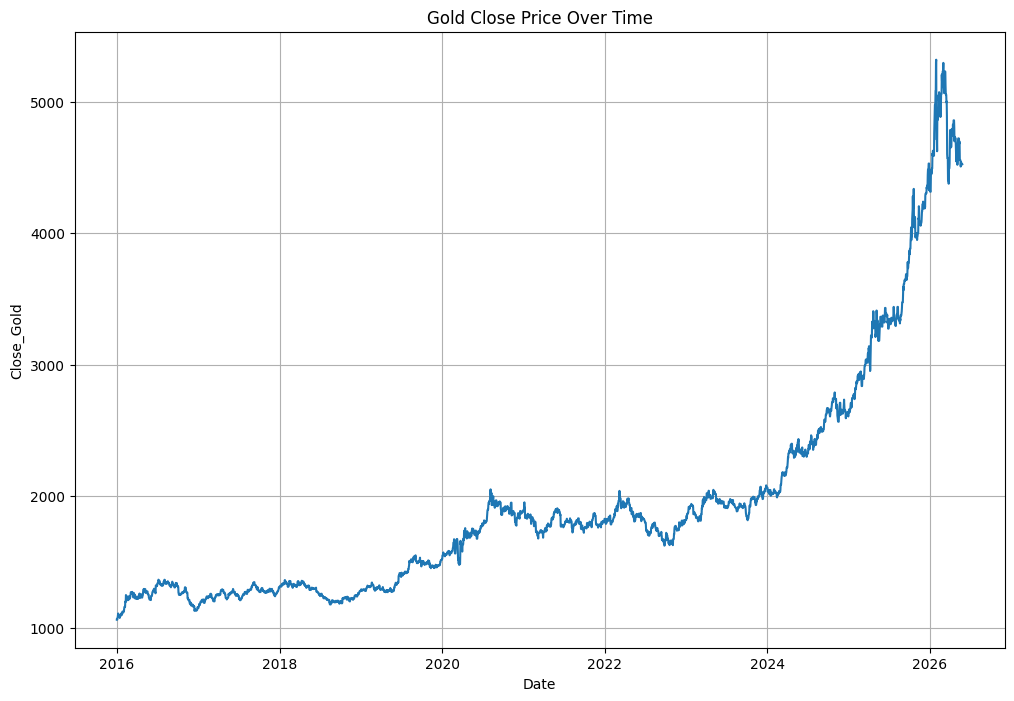

In [ ]:
plt.plot(data.index, data['Close_Gold'])
plt.xlabel('Date')
plt.ylabel('Close_Gold')
plt.title('Gold Close Price Over Time')
plt.grid(True)
plt.show()

<Axes: >

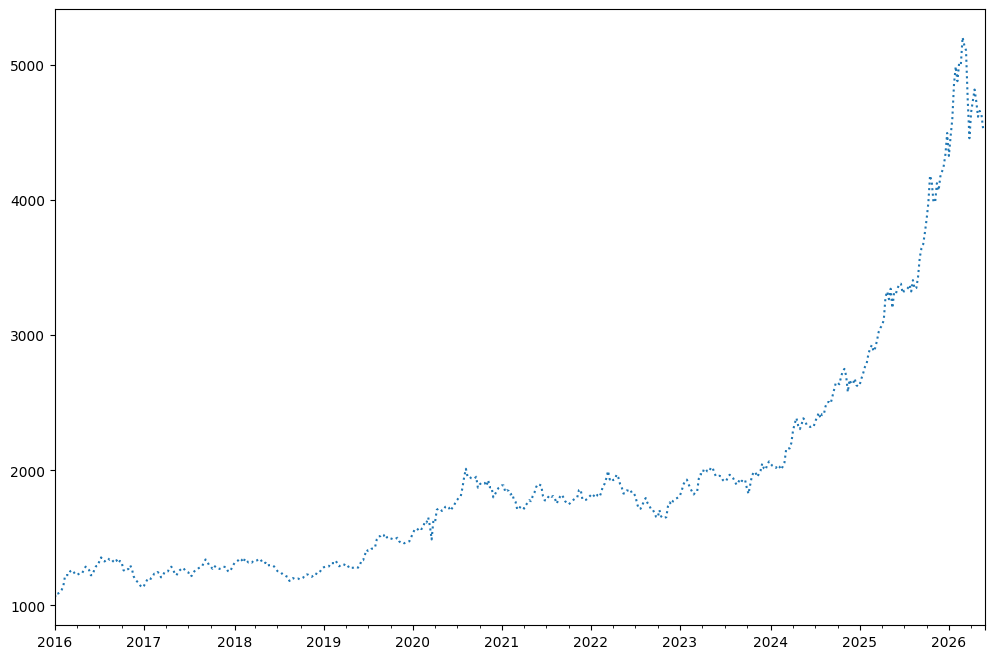

In [ ]:
weekly = data['Close_Gold'].resample('W').mean()
weekly.plot(style=[':'])

<Axes: >

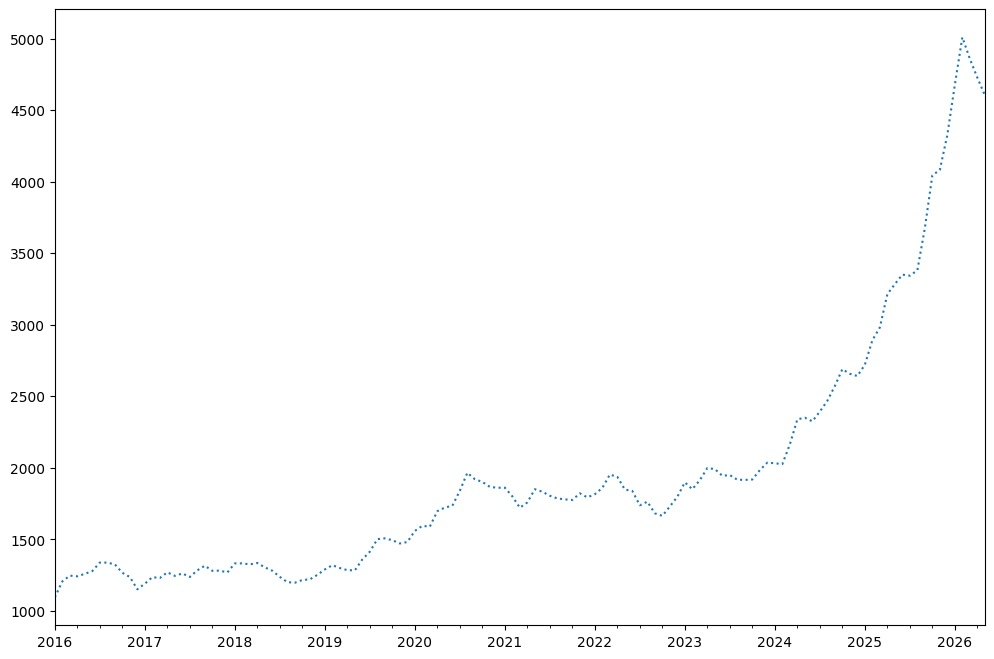

In [ ]:
monthly = data['Close_Gold'].resample('ME').mean()
monthly.plot(style=[':'])

<Axes: >

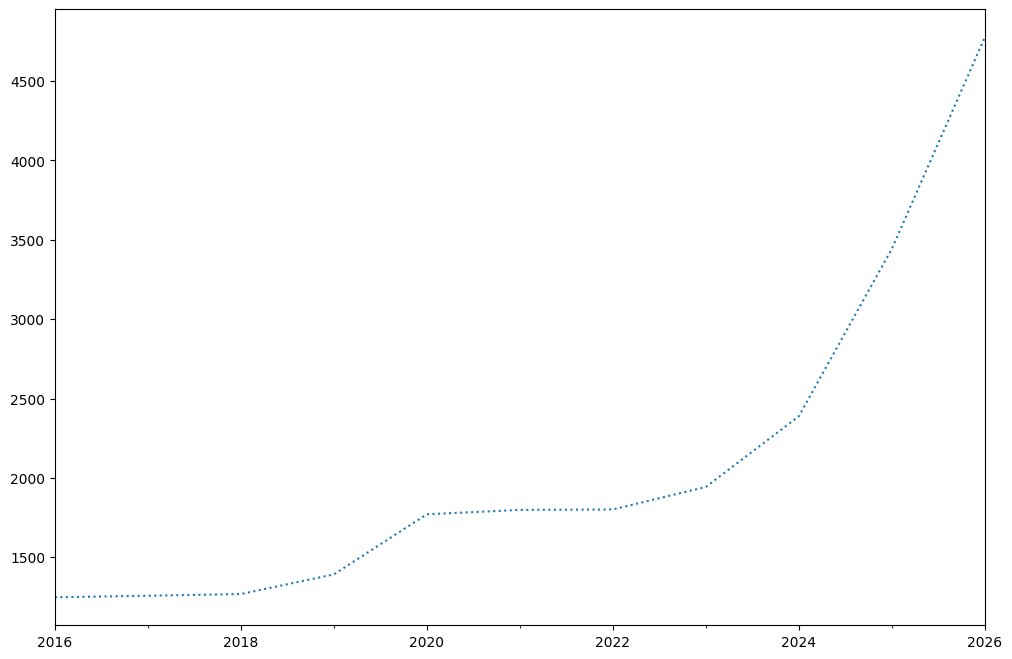

In [ ]:
yearly = data['Close_Gold'].resample('YE').mean()
yearly.plot(style=[':'])

In [ ]:
ticker = yf.Ticker("GC=F")

Gold_data = ticker.history(interval="1h", start="2025-1-01", end=end)

In [ ]:
Gold_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-01-02 00:00:00-05:00,2645.800049,2648.800049,2645.100098,2646.000000,2454,0.0,0.0
2025-01-02 01:00:00-05:00,2646.000000,2647.800049,2643.600098,2646.500000,2488,0.0,0.0
2025-01-02 02:00:00-05:00,2646.399902,2648.000000,2644.699951,2647.899902,1936,0.0,0.0
2025-01-02 03:00:00-05:00,2648.000000,2650.199951,2642.600098,2648.800049,5375,0.0,0.0
2025-01-02 04:00:00-05:00,2649.000000,2652.899902,2648.899902,2649.000000,4311,0.0,0.0


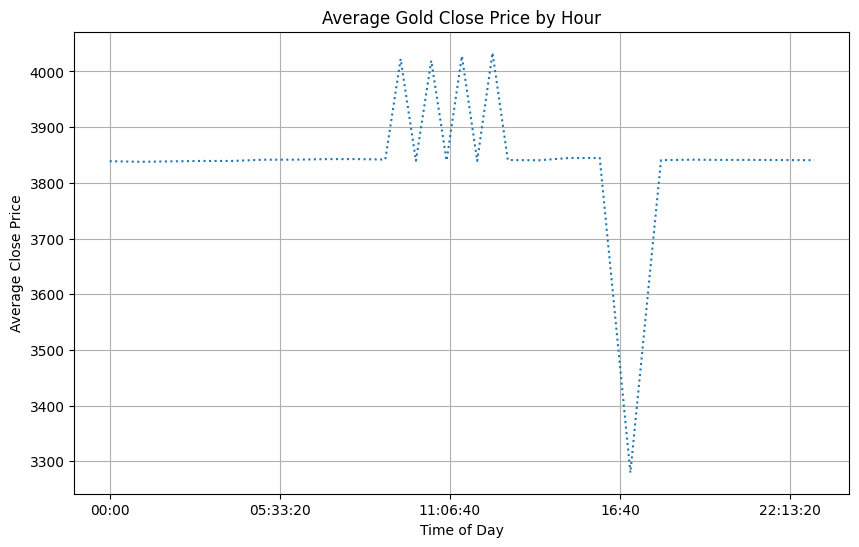

In [ ]:
# look at average gold price by hour
# transform Gold_data by using of groupby

# Check if 'Gold_data' is empty. Gold_data is expected to be loaded from previous cells.
if not Gold_data.empty:
    # Group by the time component of the DatetimeIndex and calculate the mean 'Close' price
    by_time = Gold_data['Close'].groupby(Gold_data.index.time).mean()

    plt.figure(figsize=(10, 6)) # Add a figure for proper plot display
    by_time.plot(style=[':']);
    plt.xlabel('Time of Day')
    plt.ylabel('Average Close Price')
    plt.title('Average Gold Close Price by Hour')
    plt.grid(True)
    plt.show() # Make sure the plot is shown
else:
    # If Gold_data is unexpectedly empty, print a warning.
    print("Warning: Gold_data is empty. Cannot plot hourly trends.")

**Algemeen patroon:**
Over de periode van januari 2025 tot mei 2026 ligt de gemiddelde goudprijs het
grootste deel van de dag stabiel rond **~$3.830**, zichtbaar van middernacht tot ongeveer 10:00 en weer na 17:00.

**Ochtendpiek (±10:00 – 13:00):**
Rond 11:00 stijgt de prijs fors naar **~$4.000–$4.025**. Dit sluit aan bij de
opening van de **Londense en New Yorkse goudmarkten** (LBMA en COMEX), waar het
grootste deel van de wereldwijde goudhandel plaatsvindt en prijsbewegingen het
sterkst zijn.

**Scherpe dip (±16:40):**
Er is een zeer opvallende en extreme daling naar **~$3.300**, gevolgd door een snel herstel. Gezien de dataset loopt van januari 2025 tot mei 2026 — een periode met significante geopolitieke en macro-economische gebeurtenissen — is het mogelijk dat dit een **uitschieter op een specifieke handelsdag** betreft, zoals een plotselinge nieuwsgebeurtenis. Desalniettemin verdient dit punt nader onderzoek, omdat het ook een **datakwaliteitsprobleem** kan zijn (maar sinds het direct van yahoo finance is ingelezen is er waarschijnlijk iets bijzonders gebeurt).

**Avond en nacht (na 17:00):**
Na sluiting van de Amerikaanse markt stabiliseert de prijs zich weer rond
**~$3.830**, wat het basisniveau over deze periode weerspiegelt.

**Conclusie:**
De grafiek weerspiegelt het typische intraday-handelspatroon van goud over een
periode waarin de goudprijs historisch hoog stond. De piek tijdens Europese en
Amerikaanse markturen is consistent met verwachte handelspatronen.

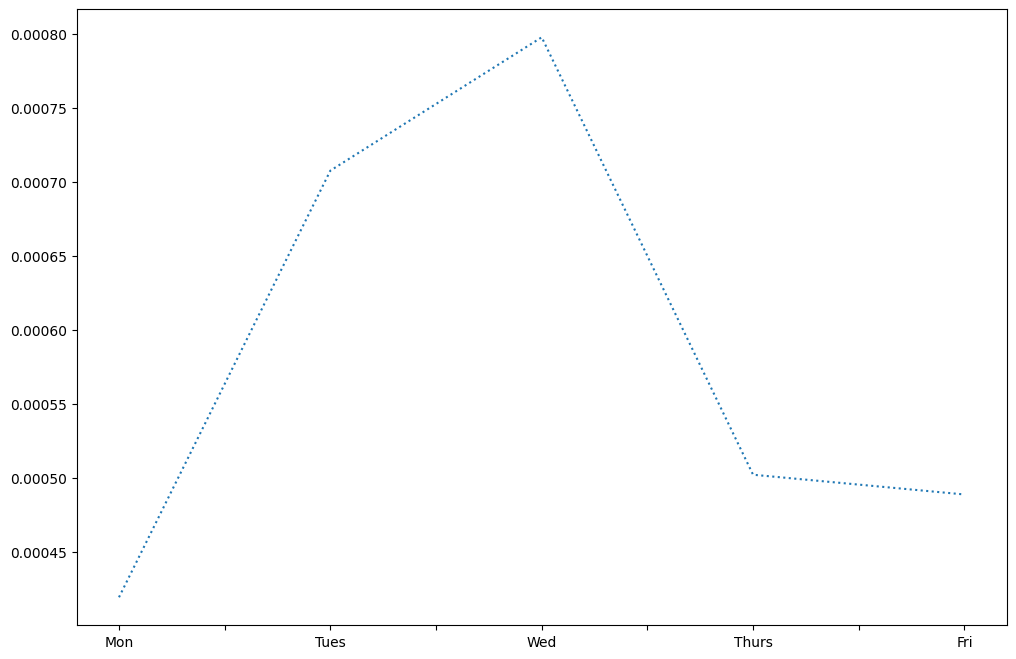

In [ ]:
samengevoegd_fil['Return'] = samengevoegd_fil['Close_Gold'].pct_change()
by_weekday = samengevoegd_fil['Return'].groupby(samengevoegd_fil.index.dayofweek).mean()
by_weekday = by_weekday[by_weekday.index < 5]
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri']
by_weekday.plot(style=[':']);

Het gemiddelde rendement stijgt van **maandag** naar een piek op
**woensdag**, om daarna scherp te dalen naar een stabiel niveau op
**donderdag en vrijdag**. Woensdag is daarmee de sterkste handelsdag
voor goud in deze periode, mogelijk gerelateerd aan wekelijkse macro-economische publicaties zoals de Fed-notulen.

In [ ]:
# Bereken rendementen per tijdsniveau
daily_returns = data['Close_Gold'].resample('D').last().pct_change()
weekly_returns = data['Close_Gold'].resample('W').last().pct_change()
monthly_returns = data['Close_Gold'].resample('ME').last().pct_change()
yearly_returns = data['Close_Gold'].resample('YE').last().pct_change()

# Bereken volatiliteit (sigma = standaarddeviatie)
sigma_daily = daily_returns.std()
sigma_weekly = weekly_returns.std()
sigma_monthly = monthly_returns.std()
sigma_yearly = yearly_returns.std()

print(f"Dag σ: {sigma_daily:.4f}")
print(f"Week σ: {sigma_weekly:.4f}")
print(f"Maand σ: {sigma_monthly:.4f}")
print(f"Jaar σ: {sigma_yearly:.4f}")

Dag σ: 0.0086
Week σ: 0.0216
Maand σ: 0.0419
Jaar σ: 0.2025


Om het verschil in volatiliteit tussen tijdsniveaus objectief te vergelijken is de standaarddeviatie (σ) van de rendementen berekend. De standaarddeviatie fungeert hierbij als maat voor volatiliteit: hoe hoger σ, hoe groter de gemiddelde afwijking van rendementen en dus hoe volatieler de koers. Uit de berekeningen blijkt dat de volatiliteit verschilt per tijdsniveau. Hierdoor kan worden geconcludeerd dat de gekozen tijdschaal invloed heeft op hoe beweeglijk de koers van goud wordt waargenomen.

##4d Timeshift

Timeshift (of lag/lead) is het verschuiven van een tijdreeks om vertraagde relaties tussen variabelen te ontdekken — bijvoorbeeld of reclame-uitgaven pas twee weken later effect hebben op de verkoop. In pandas doe je dit met df['kolom'].shift(1) voor een stap terug, of shift(-1) voor een stap vooruit. Belangrijk aandachtspunt is data leakage: gebruik nooit een lead als voorspellende feature, want dan gebruik je toekomstige informatie die je in de praktijk nog niet hebt.


**Vraag:**<br> Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?<br>
**Hypothese:**<br>
Ho: Gasoline (x5) en Close_Oil (x6) hebben geen invloed op de koers van Close_Shell (y3).<br>
H1: Gasoline (x5) en/of Close_Oil (x6) heeft invloed op de koers van Close_Shell (y3).<p>
Sinds Timeshift niet goed werkt met meerdere variabelen gaan wij hier kijken naar de onafhankelijke variabelen apart.

In [ ]:
#Plot demo
def plot_series_demo():

  # legends and annotations
  local_max = start
  offset = pd.Timedelta(30, 'D')

  ax[0].legend(['input'], loc=2)
  ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
  ax[0].axvline(local_max, alpha=0.3, color='red')

  ax[1].legend(['shift(30)'], loc=2)
  ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
  ax[1].axvline(local_max + offset, alpha=0.3, color='red')

  return

In [ ]:
#Correlation
# van chi square naar r

def chisquare2correlation(x, y):
    """
    Demonstrate relationship between chi-square and correlation

    Parameters:
    x, y: arrays of continuous data
    """
    # Calculate Pearson correlation
    r, p_value = stats.pearsonr(x, y)

    # Calculate chi-square from correlation
    n = len(x)
    chi_square_from_r = n * (r ** 2)

    print(f"Sample size (n): {n}")
    print(f"Correlation coefficient (r): {r:.4f}")
    print(f"Chi-square calculated from r: {chi_square_from_r:.4f}")


In [ ]:
#Granger
def test_granger_causality(df, maxlag=10):
    """
    Test Granger causality between two time series

    Parameters:
    df: pandas Dataframe with datetime index
    maxlag: int, maximum number of lags to test

    Returns:
    Dictionary containing test results
    """
    # Perform Granger causality tests in both directions
    print("Testing if Oil Futures (CL=F) Granger-causes Shell plc (SHEL):\n")
    gc_result1 = grangercausalitytests(df[['SHEL', 'CL=F']], maxlag=maxlag, verbose=False)

    # Extract and format results
    results = {
        'CL=F_causes_SHEL': {lag: gc_result1[lag][0]['ssr_chi2test'][1] for lag in range(1, maxlag + 1)},
    }

    return results

/tmp/ipykernel_1661/2025333719.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Oil = data['Close_Oil'].asfreq(Move_interval, method='pad')
/tmp/ipykernel_1661/2025333719.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  Oil.shift(periods=Shift_Number, freq=Move_interval).plot(ax=ax[2])


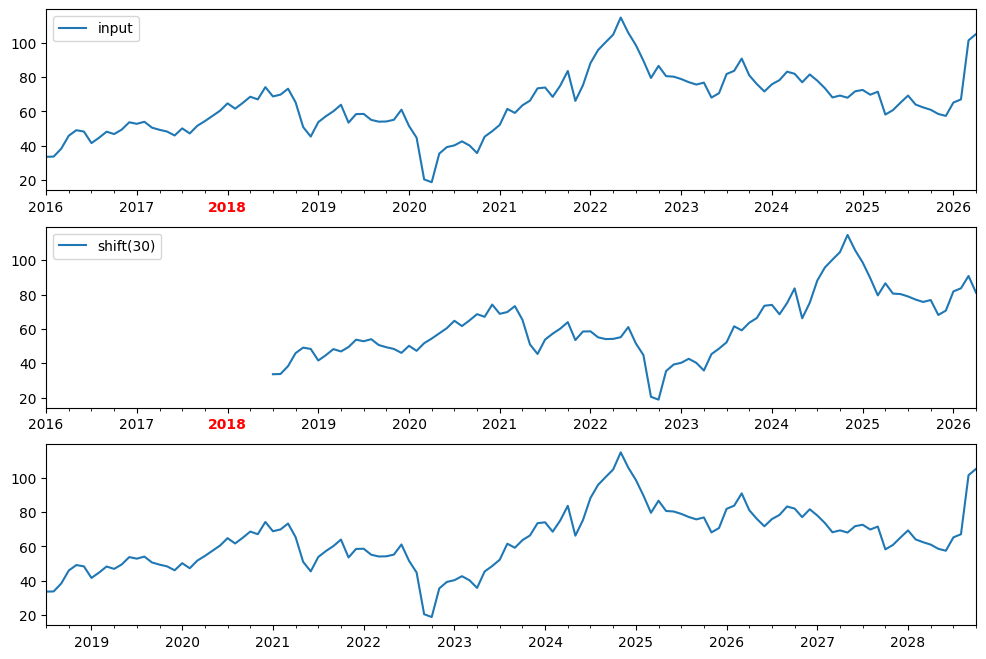

In [ ]:
#@title Use of shift()
Move_interval = 'M'
Shift_Number = 30
fig, ax = plt.subplots(3, sharey=True)

# apply a frequency to the data
Oil = data['Close_Oil'].asfreq(Move_interval, method='pad')

Oil.plot(ax=ax[0])
Oil.shift(Shift_Number).plot(ax=ax[1])
Oil.shift(periods=Shift_Number, freq=Move_interval).plot(ax=ax[2])

plot_series_demo()

/tmp/ipykernel_1661/2166340474.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  olie_daily = data['Close_Oil'].asfreq('M', method='pad')
/tmp/ipykernel_1661/2166340474.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  shell_daily = data['Close_Shell'].asfreq('M', method='pad')


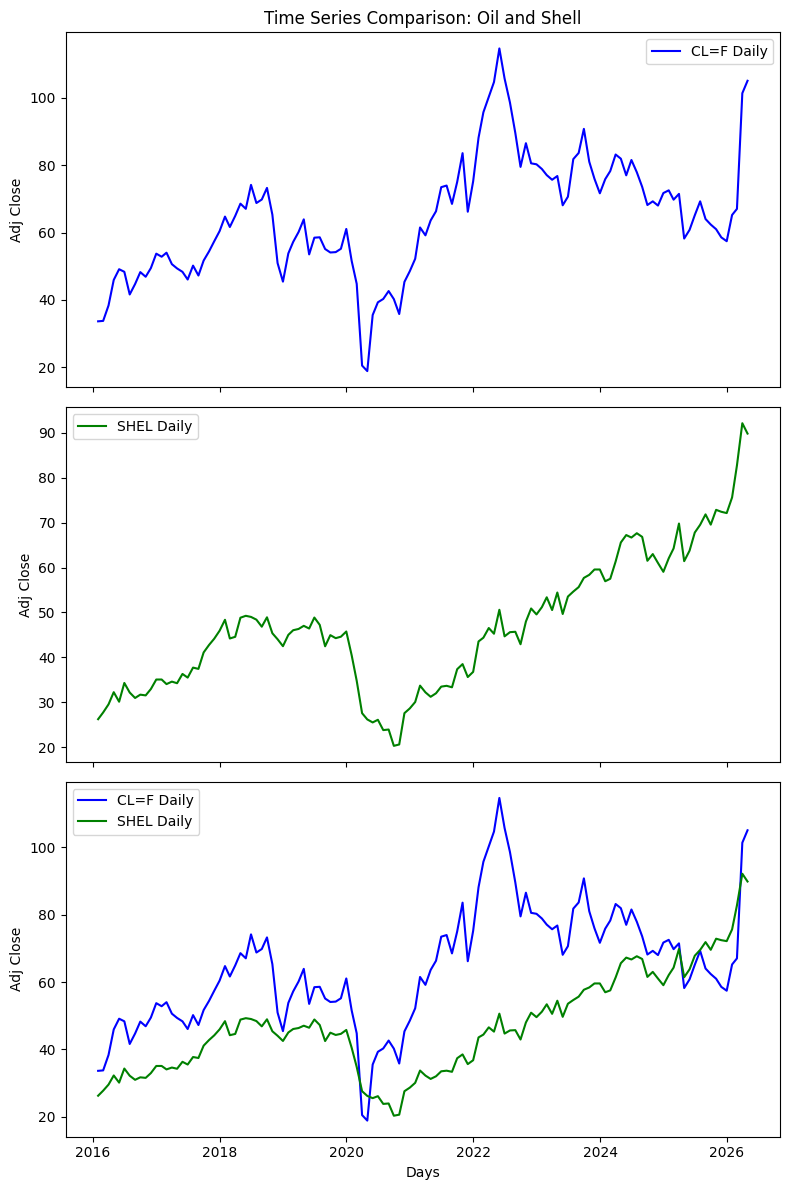

In [ ]:
# @title Combine (concat)
olie_daily = data['Close_Oil'].asfreq('M', method='pad')
shell_daily = data['Close_Shell'].asfreq('M', method='pad')

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(olie_daily, label='CL=F Daily', color='blue')
axes[0].set_title('Time Series Comparison: Oil and Shell')
axes[0].set_ylabel('Adj Close')
axes[0].legend()

axes[1].plot(shell_daily, label='SHEL Daily', color='green')
axes[1].set_ylabel('Adj Close')
axes[1].legend()

axes[2].plot(olie_daily, label='CL=F Daily', color='blue')
axes[2].plot(shell_daily, label='SHEL Daily', color='green')
axes[2].set_ylabel('Adj Close')
axes[2].legend()

# Final adjustments
plt.xlabel('Days')
plt.tight_layout()
plt.show()

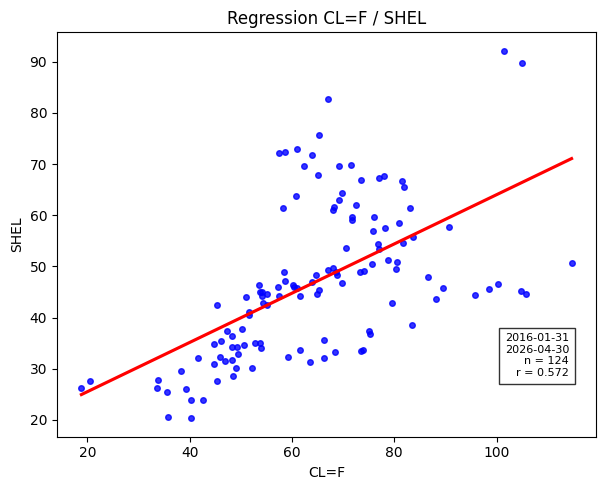

In [ ]:
# @title plot cross correlation without lag

# Samenvoegen middels concat
portfolio = pd.concat([olie_daily, shell_daily], axis=1)
portfolio.columns = ['CL=F', 'SHEL']
portfolio.head(2)

# Prepare plot
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# Date range, n, correlation coefficient, p-value
start_date = portfolio.index[0].strftime('%Y-%m-%d')
end_date = portfolio.index[-1].strftime('%Y-%m-%d')
n = len(portfolio)
correlation = stats.pearsonr(portfolio['CL=F'], portfolio['SHEL'])[0]
pvalue = stats.pearsonr(portfolio['CL=F'], portfolio['SHEL'])[1]

# Create regression plot
sns.regplot(x='CL=F', y='SHEL', data=portfolio, ci=None, ax=ax,
            scatter_kws={'s': 16, 'alpha': .8, 'color': 'blue'},
            line_kws={'color': 'red'})
ax.set_aspect('equal')
ax.set_title('Regression CL=F / SHEL')
ax.text(0.95, 0.15, f'{start_date}\n{end_date}\nn = {n}\nr = {correlation:.3f}',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8),
        horizontalalignment='right',
        fontsize=8)

plt.tight_layout()

In [ ]:
# @title create lag columns using shift

def make_lags(timeseries, lags, prefix='Lag'):
    return pd.concat(
        {
            f'{prefix}-{i}': timeseries.shift(-i)
            for i in range(1, lags + 1)
        },
        axis=1)


Xlag = make_lags(portfolio['CL=F'], lags=6, prefix='CL=F_Lag')
lags_df = pd.concat([portfolio, Xlag], axis=1)
lags_df.head(3)

,CL=F,SHEL,CL=F_Lag-1,CL=F_Lag-2,CL=F_Lag-3,CL=F_Lag-4,CL=F_Lag-5,CL=F_Lag-6
2016-01-31,33.619999,26.226273,33.750000,38.340000,45.919998,49.099998,48.330002,41.599998
2016-02-29,33.750000,27.725691,38.340000,45.919998,49.099998,48.330002,41.599998,44.700001
2016-03-31,38.340000,29.536268,45.919998,49.099998,48.330002,41.599998,44.700001,48.240002


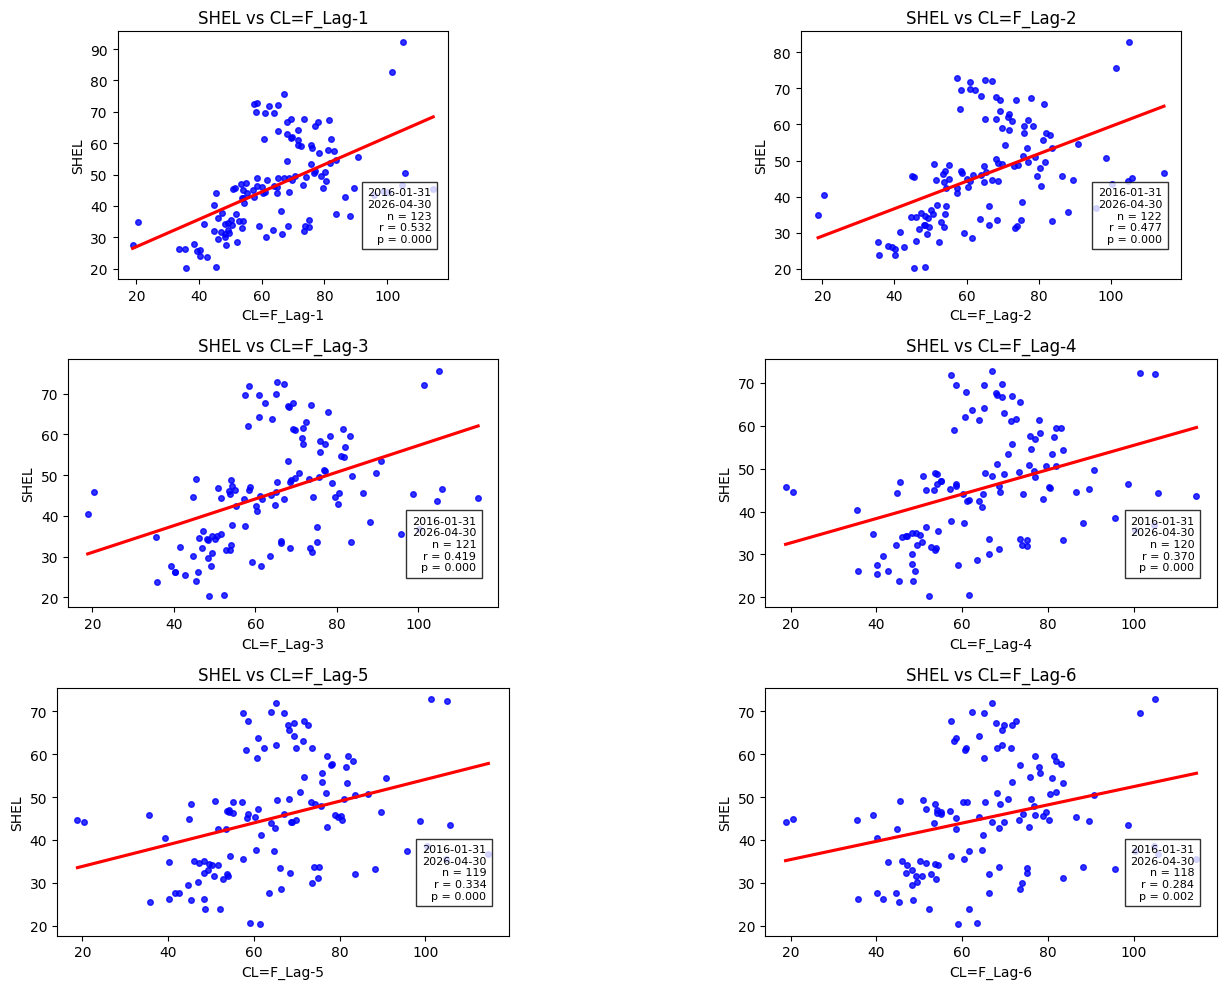

In [ ]:
# @title plot cross correlation with lag

target_col = 'SHEL'
# Filter for only the lagged CL=F columns, excluding 'CL=F' itself and 'SHEL'
comparison_cols = [col for col in lags_df.columns if col.startswith('CL=F_Lag')]

# Calculate number of rows needed for subplot grid
n_plots = len(comparison_cols)
n_rows = (n_plots + 1) // 2  # Two plots per row, rounded up
n_cols = 2

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make indexing easier

# For each comparison column
for idx, col in enumerate(comparison_cols):
    # Calculate statistics
    valid_mask = ~(lags_df[target_col].isna() | lags_df[col].isna())  # Remove NaN values
    correlation, p_value = stats.pearsonr(lags_df[target_col][valid_mask], lags_df[col][valid_mask])
    n = valid_mask.sum()
    start_date = lags_df.index[0].strftime('%Y-%m-%d')
    end_date = lags_df.index[-1].strftime('%Y-%m-%d')

    # Create scatter plot with regression line
    sns.regplot(data=lags_df, x=col, y=target_col,
                scatter_kws={'s': 16, 'alpha': .8, 'color': 'blue'},
                line_kws={'color': 'red'},
                ci=None,
                ax=axes[idx])

    # Add text box with statistics
    axes[idx].text(0.95, 0.15,
                  f'{start_date}\n{end_date}\nn = {n}\nr = {correlation:.3f}\np = {p_value:.3f}',
                  transform=axes[idx].transAxes,
                  bbox=dict(facecolor='white', alpha=0.8),
                  horizontalalignment='right',
                  fontsize=8)

    # Set title
    axes[idx].set_title(f'{target_col} vs {col}')
    axes[idx].set_aspect('equal')

# Remove any empty subplots
for idx in range(len(comparison_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Hierboven hebben we per shift (1,2,3,...) een correlatie coefficient laten berekenen. In dit voorbeeld is de hoogste correlatie coëfficient 0.532 (Close_Shell-Close_Oil).

<Figure size 1000x500 with 0 Axes>

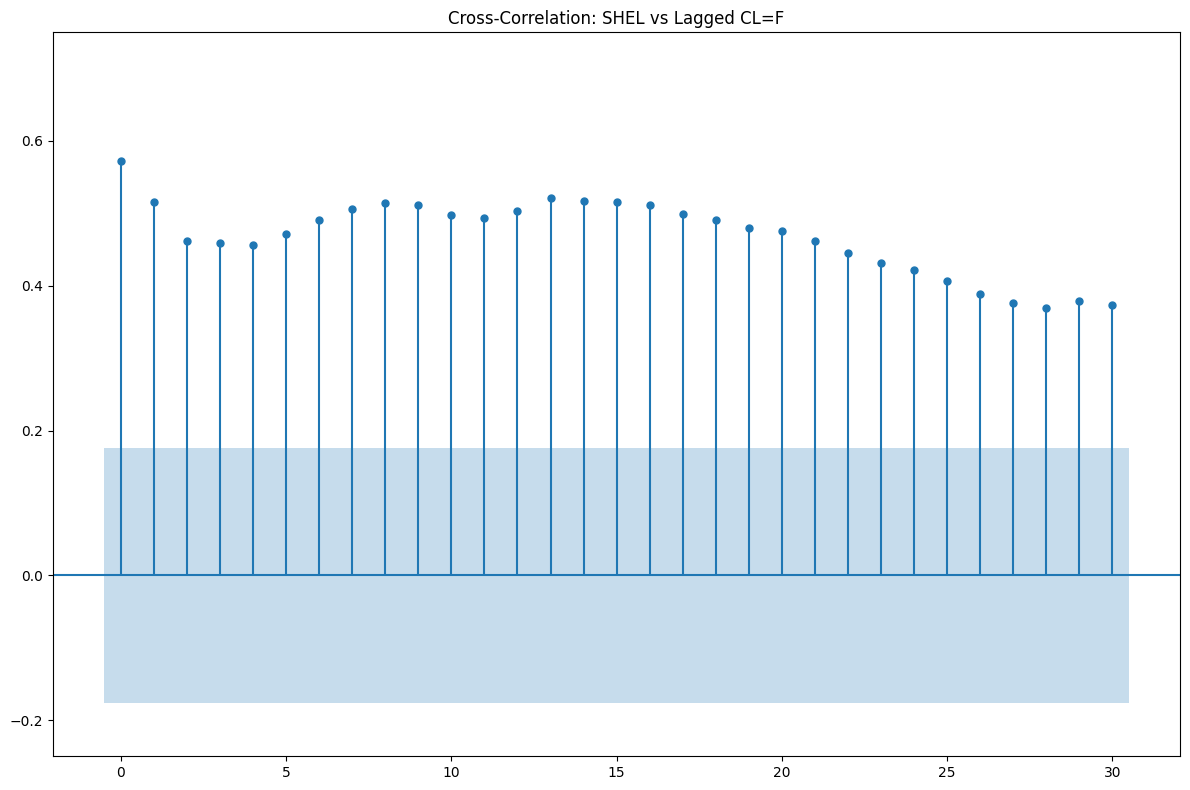

In [ ]:
# @title lag-plot (or correlogram)
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 5))

# Plot CCF (Cross-Correlation Function)
plot_ccf(lags_df['SHEL'],
         lags_df['CL=F'],
         alpha=0.05,           # 95% confidence interval
         lags=30,              # number of lags to show
         title='Cross-Correlation: SHEL vs Lagged CL=F')

plt.ylim(-0.25, 0.75) # Set y-axis range
plt.tight_layout()
plt.show()

Deze grafiek toont de cross-correlatie tussen Close_Shell (Shell aandeel) en een lagged versie van de Close_Oil (Olie koers) tijdsreeks.<p>

* De x-as toont de lags (vertragingen) van 0 tot 30 (Hier is het in maanden)
* De y-as toont de correlatiecoëfficiënten, die kunnen variëren van -1 tot +1
* De blauwe stippen verbonden met verticale lijnen tonen de correlatie voor elke lag
* Het lichtblauwe gebied rondom 0 vertegenwoordigt het 95% betrouwbaarheidsinterval

Wat we kunnen zien:

* Bij lag 0 is er een correlatie van ongeveer 0.57
* De correlaties blijven redelijk consistent positief tussen de 0.4 en de 0.6 (behalve aan het einde)
* Alle correlaties zijn statistisch significant omdat ze buiten het blauwe betrouwbaarheidsinterval vallen
* Er is een duidelijke afname van correlatie naarmate de lag toeneemt<p>

De cross-correlatie tussen SHEL en de vertraagde CL=F reeks toont een consistent positief en statistisch significant patroon over alle getoonde lags:<p>

* Er een sterke mate van persistentie is in de relatie tussen de twee reeksen
* Historische waarden blijven voorspellende waarde redelijk houden, al begint het af te lopen na 30 perioden
* Er mogelijk sprake is van een structureel verband tussen de twee reeksen<p>

Dit patroon suggereert een robuuste en aanhoudende relatie tussen SHEL en CL=F,
vermoedelijk gedreven door gedeelde fundamentele factoren zoals de olieprijs.
De afvlakking zonder nuldoorsnijding over 30 lags wijst erop dat historische
olieprijzen langdurig voorspellende waarde behouden voor SHEL, mogelijk door
trage doorwerking in winstverwachtingen en aandelenkoersen.<p>

#Lesweek 5

##Simple Sentiment Analysis

In [ ]:
def sentiment_analysis(text):
  # Create a TextBlob object
  blob = TextBlob(text)

  # Calculate the sentiment scores
  sentiment = blob.sentiment
  polarity = sentiment.polarity
  subjectivity = sentiment.subjectivity

  # Classify the polarity score as positive, negative, or neutral
  if polarity > 0:
    sentiment = 'positive'
  elif polarity == 0:
    sentiment = 'neutral'
  else:
    sentiment = 'negative'

  # Print the results
  print(f'Text: {text}')
  print(f'Sentiment: {sentiment}')
  print(f'Polarity: {polarity}')
  print(f'Subjectivity: {subjectivity}')

In [ ]:
nltk.download('vader_lexicon')

#Clear output
from google.colab import output
output.clear()

In [ ]:
ticker_symbol = 'SHEL'

company = yf.Ticker(ticker_symbol)
news = company.news

#Bedrijfsnieuws printen
for item in news:
  print(f"Title: {item['content']['title']}")
  print(f"Published: {item['content']['pubDate']}")
  print("-" * 5)

Title: Shell (SHEL) Price Target Raised Following Recent Acquisition of ARC Resources
Published: 2026-05-26T12:47:32Z
-----
Title: Energy & Utilities Roundup: Market Talk
Published: 2026-05-26T11:01:00Z
-----
Title: BP and Shell shares slide after oil prices drop on talks to end Iran war
Published: 2026-05-26T07:20:00Z
-----
Title: CIBC Confirms Neutral Rating and Target of $5.00 on Computer Modelling After Q4 Results
Published: 2026-05-25T15:36:10Z
-----
Title: Chevron Begins Drilling New Well at Egypt's Narges Gas Field
Published: 2026-05-25T14:37:00Z
-----
Title: Shell (LSE:SHEL) Valuation Check After Recent Pullback And LNG Growth Narrative
Published: 2026-05-25T14:09:39Z
-----
Title: Shell (SHEL) Upgraded to Buy Following ARC Resources Deal
Published: 2026-05-24T17:30:31Z
-----
Title: Alaska’s Oil Revival Sparks a New Energy Rush Into the Arctic
Published: 2026-05-24T14:15:00Z
-----
Title: Why Shell’s (SHEL) Capital Return Strategy Is Back In Focus
Published: 2026-05-24T11:50:18Z


In [ ]:
# Model VADER (VA)
# Model TextBlob (TB)
# Model Hugging Face (HF)

sia = SentimentIntensityAnalyzer()

sentiment_analyzer = pipeline("sentiment-analysis",
                             model="distilbert-base-uncased-finetuned-sst-2-english"
)

table_data = []
VA_scores = []
TB_scores = []
HF_positive = []
HF_negative = []

# Use all three models and get sentiment scores from headlines
for article in news:
    VA_sentiment = sia.polarity_scores(article['content']['title'])  # Get sentiment scores
    VA_score = VA_sentiment['compound']
    VA_scores.append(VA_score)

    TB_blob = TextBlob(article['content']['title'])
    TB_score = TB_blob.sentiment.polarity  # Compound-like score from TextBlob
    TB_scores.append(TB_score)

    HF_result = sentiment_analyzer(article['content']['title'])[0]
    HF_label = HF_result['label']
    HF_score = HF_result['score']

    if HF_label == "POSITIVE":
        HF_positive.append(HF_score)
    elif HF_label == "NEGATIVE":
        HF_negative.append(HF_score)
        HF_score = -HF_score  # Make the score negative for "NEGATIVE" labels

    pub_date = dt.datetime.strptime(article['content']['pubDate'], '%Y-%m-%dT%H:%M:%SZ')
    timestamp = pub_date.timestamp()

    table_data.append([dt.datetime.fromtimestamp(timestamp),article['content']['title'][:60], VA_score, TB_score, HF_score])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Calculate the average score
VA_average_score = sum(VA_scores) / len(VA_scores)
TB_average_score = sum(TB_scores) / len(TB_scores)

if HF_positive and HF_negative:
  HF_average_score = (sum(HF_positive) - sum(HF_negative)) / (len(HF_positive)+len(HF_negative))
else:
  HF_average_score = 0 #if table_data else 0

table_data.append(["","Average Scores", VA_average_score, TB_average_score, HF_average_score])

headers = ["Date", "Headline", "VA Score", "TB Score", "HF Score"]
print(tabulate(table_data, headers=headers, tablefmt="grid", numalign="right", stralign="left", floatfmt=".4f"))

+---------------------+--------------------------------------------------------------+------------+------------+------------+
| Date                | Headline                                                     |   VA Score |   TB Score |   HF Score |
+=====================+==============================================================+============+============+============+
| 2026-05-26 12:47:32 | Shell (SHEL) Price Target Raised Following Recent Acquisitio |     0.0000 |     0.0000 |    -0.9721 |
+---------------------+--------------------------------------------------------------+------------+------------+------------+
| 2026-05-26 11:01:00 | Energy & Utilities Roundup: Market Talk                      |     0.2732 |     0.0000 |     0.9314 |
+---------------------+--------------------------------------------------------------+------------+------------+------------+
| 2026-05-26 07:20:00 | BP and Shell shares slide after oil prices drop on talks to  |    -0.5859 |     0.0000 |    -0

In [ ]:
df_Sentiment = pd.DataFrame(table_data, columns=headers)  # Create the DataFrame
df_Sentiment = df_Sentiment.dropna()
df_Sentiment

,Date,Headline,VA Score,TB Score,HF Score
0,2026-05-26 12:47:32,Shell (SHEL) Price Target Raised Following Rec...,0.00000,0.000000,-0.972126
1,2026-05-26 11:01:00,Energy & Utilities Roundup: Market Talk,0.27320,0.000000,0.931412
2,2026-05-26 07:20:00,BP and Shell shares slide after oil prices dro...,-0.58590,0.000000,-0.981820
3,2026-05-25 15:36:10,CIBC Confirms Neutral Rating and Target of $5....,0.00000,0.000000,-0.998467
4,2026-05-25 14:37:00,Chevron Begins Drilling New Well at Egypt's Na...,0.27320,0.136364,-0.520342
5,2026-05-25 14:09:39,Shell (LSE:SHEL) Valuation Check After Recent ...,0.38180,0.000000,-0.978758
6,2026-05-24 17:30:31,Shell (SHEL) Upgraded to Buy Following ARC Res...,0.00000,0.000000,0.673539
7,2026-05-24 14:15:00,Alaska’s Oil Revival Sparks a New Energy Rush ...,0.27320,0.136364,0.999493
8,2026-05-24 11:50:18,Why Shell’s (SHEL) Capital Return Strategy Is ...,0.00000,0.000000,-0.984337
9,2026-05-22 15:00:57,Shell's 45% Emissions Fight Reaches Dutch Supr...,0.29600,0.000000,-0.928377


In [ ]:
df_Sentiment.to_excel('output.xlsx', index=False)

In [ ]:
hf_score_df = df_Sentiment[["Date", "HF Score"]].copy()
hf_score_df

,Date,HF Score
0,2026-05-26 12:47:32,-0.972126
1,2026-05-26 11:01:00,0.931412
2,2026-05-26 07:20:00,-0.981820
3,2026-05-25 15:36:10,-0.998467
4,2026-05-25 14:37:00,-0.520342
5,2026-05-25 14:09:39,-0.978758
6,2026-05-24 17:30:31,0.673539
7,2026-05-24 14:15:00,0.999493
8,2026-05-24 11:50:18,-0.984337
9,2026-05-22 15:00:57,-0.928377


In [ ]:
hf_score_df = hf_score_df.dropna()
hf_score_df = hf_score_df[:-1]
hf_score_df

,Date,HF Score
0,2026-05-26 12:47:32,-0.972126
1,2026-05-26 11:01:00,0.931412
2,2026-05-26 07:20:00,-0.981820
3,2026-05-25 15:36:10,-0.998467
4,2026-05-25 14:37:00,-0.520342
5,2026-05-25 14:09:39,-0.978758
6,2026-05-24 17:30:31,0.673539
7,2026-05-24 14:15:00,0.999493
8,2026-05-24 11:50:18,-0.984337
9,2026-05-22 15:00:57,-0.928377


In [ ]:
hf_score_df.sort_values(by=['Date'], inplace=True)
hf_score_df

,Date,HF Score
9,2026-05-22 15:00:57,-0.928377
8,2026-05-24 11:50:18,-0.984337
7,2026-05-24 14:15:00,0.999493
6,2026-05-24 17:30:31,0.673539
5,2026-05-25 14:09:39,-0.978758
4,2026-05-25 14:37:00,-0.520342
3,2026-05-25 15:36:10,-0.998467
2,2026-05-26 07:20:00,-0.981820
1,2026-05-26 11:01:00,0.931412
0,2026-05-26 12:47:32,-0.972126


In [ ]:
hf_score_df['Date'] = pd.to_datetime(hf_score_df['Date']).dt.date
hf_score_df

,Date,HF Score
9,2026-05-22,-0.928377
8,2026-05-24,-0.984337
7,2026-05-24,0.999493
6,2026-05-24,0.673539
5,2026-05-25,-0.978758
4,2026-05-25,-0.520342
3,2026-05-25,-0.998467
2,2026-05-26,-0.981820
1,2026-05-26,0.931412
0,2026-05-26,-0.972126


In [ ]:
sentiment_df_daily = hf_score_df.groupby('Date')['HF Score'].mean()
sentiment_df_daily

,HF Score
Date,
2026-05-22,-0.928377
2026-05-24,0.229565
2026-05-25,-0.832523
2026-05-26,-0.340844


In [ ]:
start_date = "2026-05-14"
end_date = "2026-05-18"

df = yf.download("SHEL", start=start_date, end=end_date)
df_close = df['Close']  # Maak een nieuw dataframe met alleen de Close-koers
df_close

/tmp/ipykernel_1661/1625997324.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SHEL", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Ticker,SHEL
Date,
2026-05-14,83.750549
2026-05-15,84.592911


In [ ]:
combined_df = pd.concat([df_close, sentiment_df_daily], axis=1)
combined_df

,SHEL,HF Score
Date,,
2026-05-14 00:00:00,83.750549,NaN
2026-05-15 00:00:00,84.592911,NaN
2026-05-22,NaN,-0.928377
2026-05-24,NaN,0.229565
2026-05-25,NaN,-0.832523
2026-05-26,NaN,-0.340844


In [ ]:
combined_df = combined_df.ffill()
combined_df = combined_df.bfill()
combined_df

,SHEL,HF Score
Date,,
2026-05-14 00:00:00,83.750549,-0.928377
2026-05-15 00:00:00,84.592911,-0.928377
2026-05-22,84.592911,-0.928377
2026-05-24,84.592911,0.229565
2026-05-25,84.592911,-0.832523
2026-05-26,84.592911,-0.340844


In [ ]:
# Maak de OLS-regressie
X = combined_df['HF Score']  # Onafhankelijke variabele
y = combined_df['SHEL']  # Afhankelijke variabele

# Voeg een constante term toe aan de regressiematrix
X = sm.add_constant(X)

# Voer de OLS-regressie uit
model = sm.OLS(y, X)
results = model.fit()

# Print de samenvatting van de OLS-regressie
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   SHEL   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                 -0.125
Method:                 Least Squares   F-statistic:                    0.4445
Date:                Tue, 26 May 2026   Prob (F-statistic):              0.541
Time:                        13:40:19   Log-Likelihood:                -1.2460
No. Observations:                   6   AIC:                             6.492
Df Residuals:                       4   BIC:                             6.076
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         84.5947      0.260    325.256      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


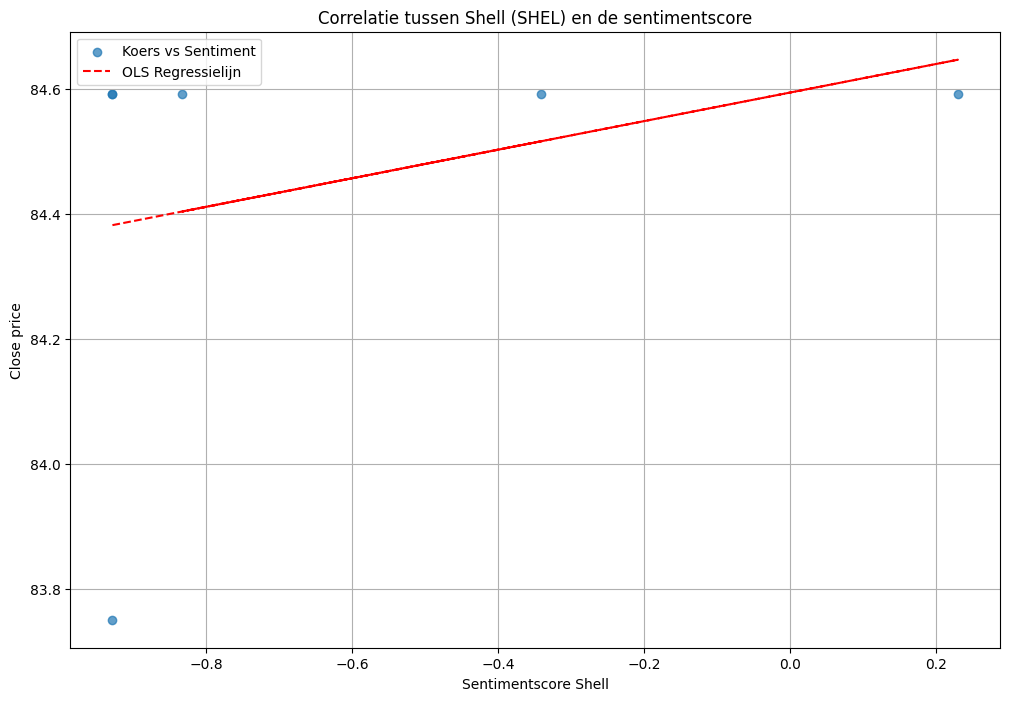

In [ ]:
# Maak de scatter plot om de correlatie weer te geven
#plt.figure(figsize=(10, 6))
plt.scatter(combined_df["HF Score"], combined_df['SHEL'], alpha=0.7, label="Koers vs Sentiment")

# Voeg de regressielijn toe (de voorspellingen van de OLS-regressie)
plt.plot(combined_df["HF Score"], results.fittedvalues, "r--", label="OLS Regressielijn")

# Gebruik een FuncFormatter om het decimale getal op de y-as weg te laten als het 0 is en af te ronden op 1 decimaal
def remove_zero_formatter(x, pos):
    return f'{x:.1f}' if not x.is_integer() else f'{x:.0f}'

# Pas de formatter toe op de y-as
plt.gca().yaxis.set_major_formatter(FuncFormatter(remove_zero_formatter))

# Grafiekinstellingen
plt.title("Correlatie tussen Shell (SHEL) en de sentimentscore")
plt.xlabel("Sentimentscore Shell")
plt.ylabel("Close price")
plt.legend()
plt.grid(True)
plt.show()

###Toelichting sentimentanalyse

Voor de sentimentanalyse is onderzocht hoe nieuwsberichten over Shell (SHEL) positief, negatief of neutraal worden beoordeeld en of deze sentimenten mogelijk samenhangen met de aandelenkoers.

Hiervoor zijn nieuwsartikelen verzameld en geanalyseerd met drie verschillende modellen: VADER, TextBlob en Hugging Face (DistilBERT).

VADER berekent een sentimentscore tussen -1 en +1, waarbij positieve waarden positief nieuws aangeven en negatieve waarden negatief nieuws.

TextBlob bepaalt een polariteitsscore en geeft daarnaast inzicht in de subjectiviteit van de tekst.

Het Hugging Face-model gebruikt machine learning om sentiment te classificeren en geeft een betrouwbaarheidsscore mee.

De gemiddelde sentimentscores zijn vervolgens gekoppeld aan de dagelijkse slotkoers van Shell om te onderzoeken of nieuws en marktsentiment invloed hebben op koersbewegingen.

Deze analyse draagt bij aan de onderzoeksvraag doordat wordt onderzocht of nieuwsberichten invloed kunnen hebben op het gedrag van beleggers en daarmee op de aandelenkoers.

#Lesweek 6

Neural Network

##Neuraal netwerk voor regressie vraag 5

Onderzoeksvraag 5: Wat is het verband tussen Coffee (x7), Copper (x4), Close_Gold (x8) en Close_Apple (y4)?

In [ ]:
X = data[["Coffee", "Copper", "Close_Gold"]]
y = data["Close_Apple"]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.6)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

In [ ]:
model = MLPRegressor(hidden_layer_sizes = (64, 64, 64),
                     activation = "relu",
                     random_state = 42, max_iter = 2000)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [ ]:
mae = metrics.mean_absolute_error(y_val, y_pred)
mse = metrics.mean_squared_error(y_val, y_pred)
rmse = mse**0.5
r2 = metrics.r2_score(y_val, y_pred)


print(f"""
Mean Absolute Error: \t{mae:.2f}
Root Mean Square Error: \t{rmse:.2f}
r2: \t{r2:.2f}
""")


Mean Absolute Error: 	7.81
Root Mean Square Error: 	10.76
r2: 	0.98



Je zit er dus met dit voorspelmodel gemiddeld tussen de 7,85 en 10,81 dollar naast.<br>
De r-kwadraat is hoog: 0,98 - dit suggereert een sterk verband tussen de X'n (Coffee, Copper en Close_Gold)) en de Y (koers van Close_Apple).

In [ ]:
df = pd.DataFrame()

df['Koers_Appel'] = y_val
df['Voorspelde_koers_Appel'] = y_pred


weight = df[['Koers_Appel', 'Voorspelde_koers_Appel']].pct_change(axis = 'columns', periods = 1 ).abs()
total = sum(weight['Voorspelde_koers_Appel'])

average_miscalc = (total / len(weight)) * 100
print(f"De afwijking tussen de koers en de voorspelde koers is gemiddeld {round(average_miscalc, 2)} % \n\n\n" )

De afwijking tussen de koers en de voorspelde koers is gemiddeld 8.14 % 





###Scatterplot

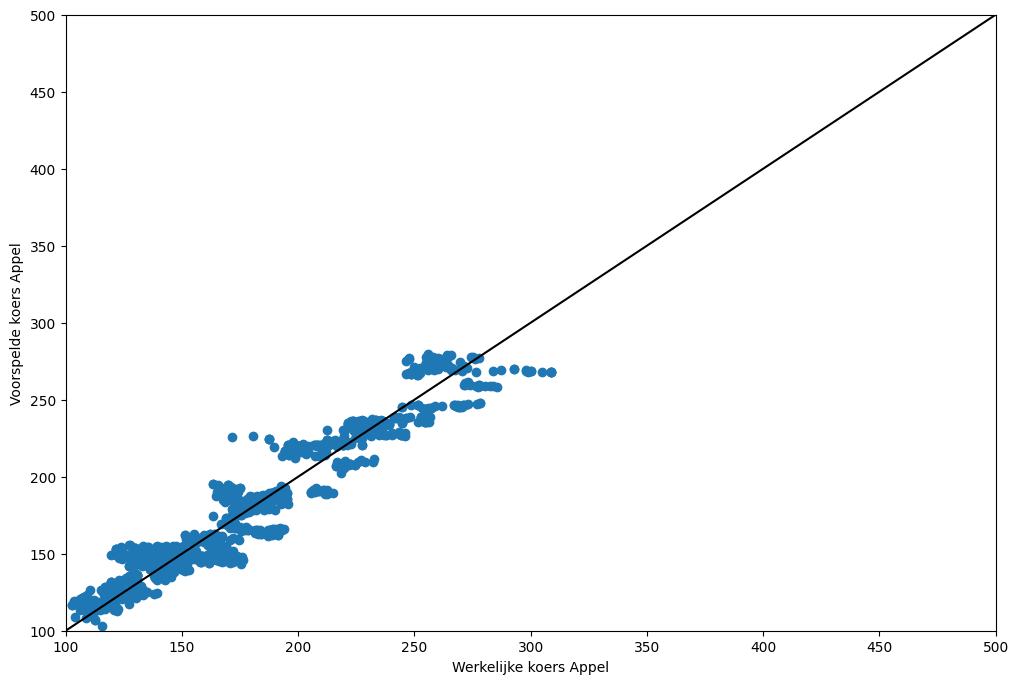

In [ ]:
plt.scatter(y_val, y_pred)
plt.xlim(100, 500)
plt.ylim(100, 500)
plt.ylabel('Voorspelde koers Appel')
plt.xlabel('Werkelijke koers Appel')
plt.plot([0, 500], [0,500], 'black') #1 to 1 line
plt.show()

In de scatterplot is te zien dat de koers vrij goed overeen komt met de voorspelde waarde.

##SVM voor regressie vraag 4

Onderzoeksvraag 4: Waarom lijkt het dat er minder verband is tussen Gasoline (x5), Close_Oil (x6) en Close_Shell (y3)?


In [ ]:
# Prepare the data using daily returns from dag_rendement
# Categorize 'Close_Shell' returns into 'Increase' or 'Decrease'
# Assuming 0 or positive return is 'Increase', negative is 'Decrease'
y_svm_target = (dag_rendement['Close_Shell'] > 0).astype(int) # 1 for Increase, 0 for Decrease

# Features are 'Gasoline' and 'Close_Oil' returns
X_svm_features = dag_rendement[['Gasoline', 'Close_Oil']]

# Drop any remaining NaNs to ensure consistent data length
X_svm_features, y_svm_target = X_svm_features.align(y_svm_target, join='inner', axis=0)

# Split data into training and testing sets
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm_features,
    y_svm_target,
    test_size=0.3, # 30% for testing
    random_state=42
)

# Standardize the features (important for SVMs)
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

# Initialize and train the SVM model
# Using a linear kernel initially, but other kernels (e.g., 'rbf') could be explored
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_svm_scaled, y_train_svm)

# Make predictions on the scaled test set
y_pred_svm = model_svm.predict(X_test_svm_scaled)

# Evaluate the model
print("--- Support Vector Machine (SVM) Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_svm))

print("\nDe resultaten laten zien in hoeverre de dagelijkse rendementen van Gasoline en Close_Oil kunnen helpen om een stijging of daling van Close_Shell te voorspellen met een SVM-model.")

--- Support Vector Machine (SVM) Classification Results ---
Accuracy: 0.75

Confusion Matrix:
[[689  37]
 [253 160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.95      0.83       726
           1       0.81      0.39      0.52       413

    accuracy                           0.75      1139
   macro avg       0.77      0.67      0.68      1139
weighted avg       0.76      0.75      0.72      1139


De resultaten laten zien in hoeverre de dagelijkse rendementen van Gasoline en Close_Oil kunnen helpen om een stijging of daling van Close_Shell te voorspellen met een SVM-model.


De resultaten laten zien in hoeverre de dagelijkse rendementen van **Gasoline** en **Close_Oil** kunnen helpen om een stijging of daling van **Close_Shell** te voorspellen met behulp van een **Support Vector Machine (SVM)** classificatiemodel.

###Accuracy
De accuracy van het model bedraagt **0,75 (75%)**. Dit betekent dat het model in **75% van alle gevallen** de juiste voorspelling maakt. Hoewel dit een redelijk resultaat is, geeft accuracy alleen niet het volledige beeld van de prestaties, vooral wanneer de verdeling tussen de klassen ongelijk is.

###Confusion Matrix
De confusion matrix geeft inzicht in welke voorspellingen correct en incorrect zijn gemaakt:

| Werkelijke waarde | Voorspeld: 0 | Voorspeld: 1 |
|-------------------|--------------|--------------|
| 0 | 689 | 37 |
| 1 | 253 | 160 |

Hierbij geldt:

- **689 True Negatives (TN):** Het model voorspelde correct een daling (klasse 0).
- **37 False Positives (FP):** Het model voorspelde een stijging terwijl er in werkelijkheid een daling was.
- **253 False Negatives (FN):** Het model voorspelde een daling terwijl er daadwerkelijk een stijging plaatsvond.
- **160 True Positives (TP):** Het model voorspelde correct een stijging (klasse 1).

De confusion matrix laat zien dat het model aanzienlijk beter presteert in het herkennen van **klasse 0 (daling)** dan **klasse 1 (stijging)**.

###Precision
Precision geeft aan hoeveel van de voorspelde positieve waarden daadwerkelijk positief waren.

- **Klasse 0:** 0,73  
- **Klasse 1:** 0,81  

Voor klasse 1 betekent een precision van **81%** dat wanneer het model een stijging voorspelt, dit in 81% van de gevallen daadwerkelijk klopt.

###Recall
Recall geeft aan hoeveel van de werkelijke gevallen correct zijn herkend.

- **Klasse 0:** 0,95  
- **Klasse 1:** 0,39  

De recall voor klasse 1 is relatief laag (**39%**). Dit betekent dat het model slechts 39% van alle werkelijke stijgingen correct identificeert en dus veel stijgingen mist.

###F1-score
De F1-score combineert precision en recall in één maatstaf.

- **Klasse 0:** 0,83  
- **Klasse 1:** 0,52  

De relatief lage F1-score voor klasse 1 toont aan dat het model moeite heeft met het herkennen van stijgingen van het aandeel Shell.

###Algemene interpretatie
De resultaten suggereren dat de dagelijkse rendementen van **Gasoline** en **Close_Oil** een zekere voorspellende waarde hebben voor de beweging van **Close_Shell**, maar dat de voorspellende kracht beperkt is. Hoewel het model een redelijke algemene nauwkeurigheid behaalt van 75%, blijkt dat het model sterk gericht is op het voorspellen van dalingen en minder goed in staat is om stijgingen correct te identificeren.

De lage recall voor klasse 1 wijst erop dat veel stijgende bewegingen niet worden herkend. Dit kan erop wijzen dat aanvullende variabelen, zoals marktindicatoren, macro-economische factoren of historische Shell-data, nodig zijn om de voorspellende prestaties verder te verbeteren.

###Conclusie
Het SVM-model levert acceptabele algemene prestaties, maar vertoont een duidelijke onbalans tussen het herkennen van stijgingen en dalingen. Hierdoor is het model bruikbaar als eerste indicatie van marktbewegingen, maar minder geschikt wanneer het doel is om specifiek stijgende koersbewegingen nauwkeurig te voorspellen.

#Lesweek 7